In [124]:
# conda activate chronocell

import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("code")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

import Chronocell
from impute_protein import *
from protein_from_RNA import *

# Prep data

In [125]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

In [126]:
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Names of genes in Chronocell object
genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv")

In [127]:
cell_meta = pd.read_csv(f"data/{prefix}_traj_X_row_metadata.csv")

expr_ADT_imputed = pd.read_csv(f"data/{prefix}_RNA_history_imputed_protein.csv")
expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

In [128]:
# Subset to genes with imputed protein
orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
orig_corr = orig_corr[orig_corr['Gene'].isin(expr_ADT_imputed.columns)]

In [129]:
t = traj.t
Q = traj.Q[:, 0, :]

In [130]:
# Make sure order of cells matches

expr_ADT_imputed.index = cell_meta['Cell_ID']

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [131]:
expr_RNA = expr_RNA.loc[expr_ADT_imputed.index]
expr_ADT = expr_ADT.loc[expr_ADT_imputed.index]

In [132]:
np.all(expr_ADT_imputed.index == expr_ADT.index)

np.True_

In [133]:
np.all(expr_ADT_imputed.index == expr_RNA.index)

np.True_

In [134]:
# Order cells by their inferred place in time

In [135]:
Q_max_idx = np.argmax(Q, axis=1) # Get index of each cell's place in time
cell_order_idx = np.argsort(Q_max_idx) # Get ordered cells indices
cell_idx = expr_ADT.index[cell_order_idx] # Get names of cells ordered by time

expr_ADT_ordered = expr_ADT.loc[cell_idx]
expr_RNA_ordered = expr_RNA.loc[cell_idx]
expr_ADT_imputed_ordered = expr_ADT_imputed.loc[cell_idx]

In [136]:
# Time point per cell for plotting

t_per_cell = t[np.sort(Q_max_idx)]

# Plot degradation rates vs. correlation 

In [85]:
deg_df = pd.read_csv(f"data/{prefix}_degradation_rates.csv", index_col=0)
cor_df = pd.read_csv(f"data/{prefix}_eLNP_RNA_vs_ADT_corrs.csv", index_col=0)
deg_df = deg_df.merge(cor_df, left_index=True, right_on="Gene")

In [86]:
deg_df

,Deg_rate,Protein,Gene,Cor,Mean_RNA_expr,New_cor
55,0.077969,CD317,Bst2,0.077469,1.050668,0.038498
139,0.023397,CD63,Cd63,0.413217,4.793494,0.047051
148,0.021533,CD9,Cd9,0.119955,1.861176,0.026473
45,0.011552,CD29,Itgb1,0.012668,2.492147,0.041961
5,0.019782,CD107a,Lamp1,0.147878,3.021922,0.029030
106,0.011365,Mac2,Lgals3,0.008389,9.397775,0.001180
109,0.071982,Notch,Notch2,-0.001676,0.105263,-0.005782
33,0.031125,CD201,Procr,0.102938,0.832056,0.017640
4,0.044719,CD106,Vcam1,0.053864,0.523278,0.006112


In [137]:
new_order = ["Proliferating cDC1s", "Immature cDC1s", "Early mature cDC1s", "Late mature cDC1s"]

cell_meta["newClustersTmp"] = pd.Categorical(
    cell_meta["newClustersTmp"],
    categories=new_order,
    ordered=True
)

clusters = pd.Categorical(cell_meta["newClustersTmp"]) 
codes = clusters.codes 
labels = clusters.categories
cmap = plt.get_cmap("tab20", len(labels))

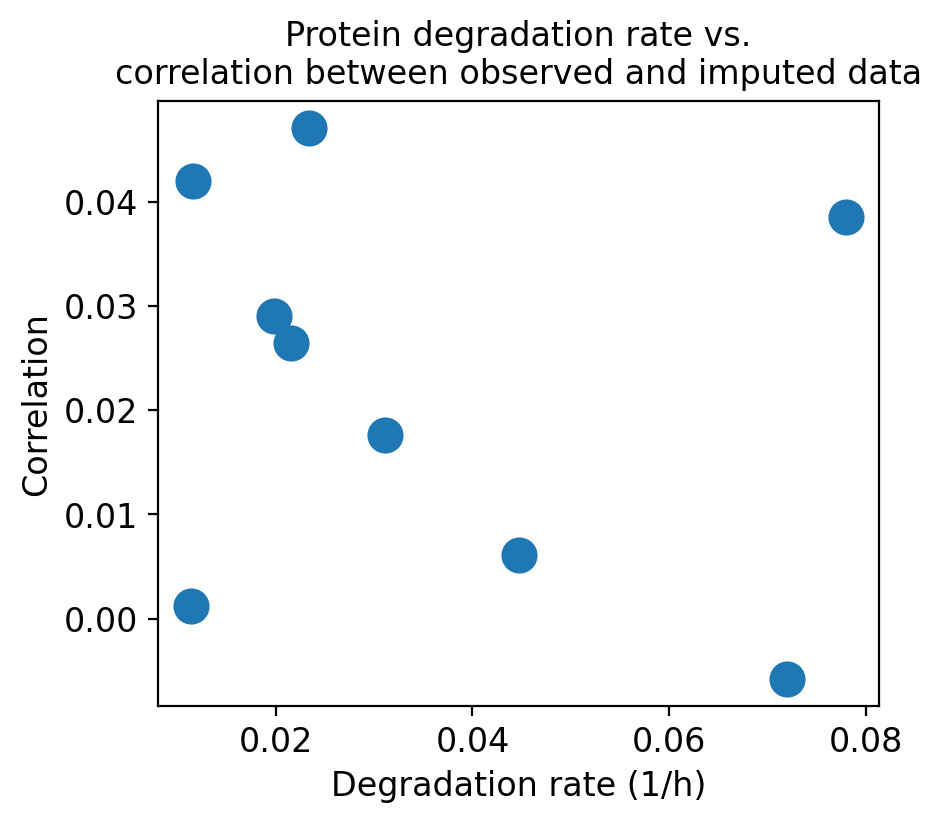

In [224]:
fig, ax = plt.subplots(figsize=(4.5, 4), dpi=200)
ax.scatter(deg_df['Deg_rate'], deg_df['New_cor'])
ax.set_title(f"Protein degradation rate vs.\ncorrelation between observed and imputed data", fontsize=12)
ax.set_xlabel("Degradation rate (1/h)", fontsize=12)
ax.set_ylabel("Correlation", fontsize=12)
ax.tick_params(labelsize=12)
plt.show()

In [217]:
deg_df

,Deg_rate,Protein,Gene,Cor,Mean_RNA_expr,New_cor
55,0.077969,CD317,Bst2,0.077469,1.050668,0.038498
139,0.023397,CD63,Cd63,0.413217,4.793494,0.047051
148,0.021533,CD9,Cd9,0.119955,1.861176,0.026473
45,0.011552,CD29,Itgb1,0.012668,2.492147,0.041961
5,0.019782,CD107a,Lamp1,0.147878,3.021922,0.029030
106,0.011365,Mac2,Lgals3,0.008389,9.397775,0.001180
109,0.071982,Notch,Notch2,-0.001676,0.105263,-0.005782
33,0.031125,CD201,Procr,0.102938,0.832056,0.017640
4,0.044719,CD106,Vcam1,0.053864,0.523278,0.006112


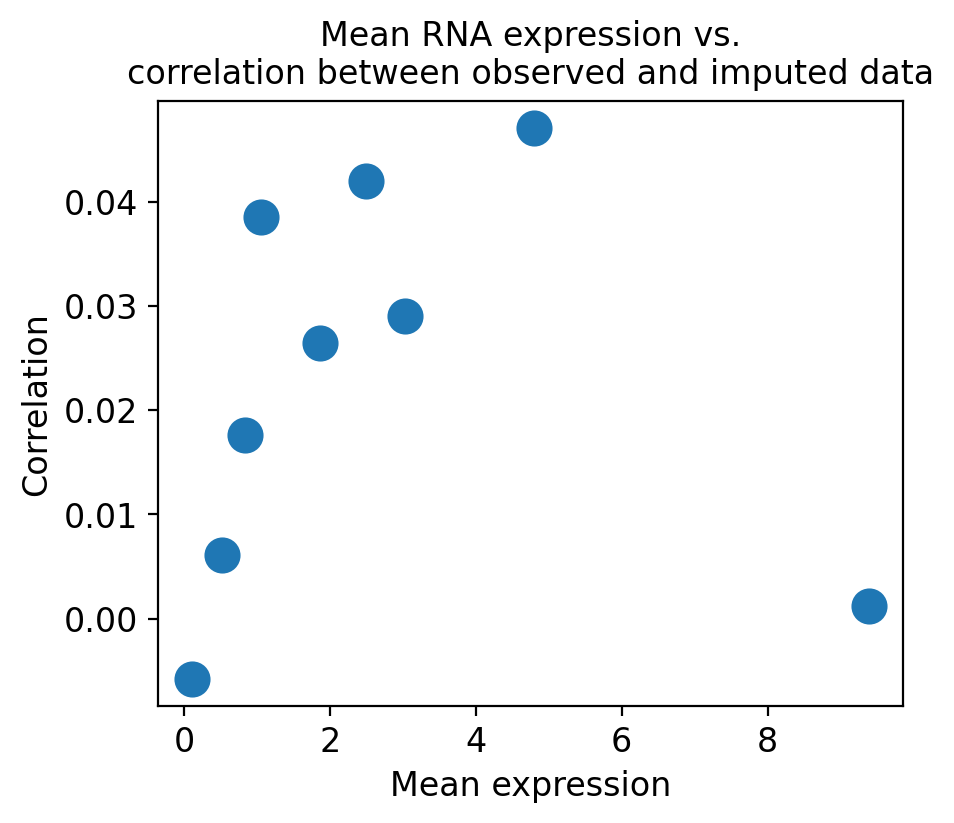

In [225]:
fig, ax = plt.subplots(figsize=(4.5, 4), dpi=200)
ax.scatter(deg_df['Mean_RNA_expr'], deg_df['New_cor'])
ax.set_title(f"Mean RNA expression vs.\ncorrelation between observed and imputed data", fontsize=12)
ax.set_xlabel("Mean expression", fontsize=12)
ax.set_ylabel("Correlation", fontsize=12)
ax.tick_params(labelsize=12)
plt.show()

# Focus on one gene/protein

In [293]:
i = 7
prot = orig_corr['Protein'].iloc[i]
gene = orig_corr['Gene'].iloc[i]

print(prot, gene)
print("Cor:", orig_corr['Cor'].iloc[i])

CD63 Cd63
Cor: 0.413217170567059


In [294]:
# Load imputed RNA for working gene

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw = pickle.load(f)
    
X_bw_ordered = X_bw[cell_order_idx, :] # Order cells by time

## Plot observed RNA and protein

/tmp/ipykernel_4061452/1601259638.py:33: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped


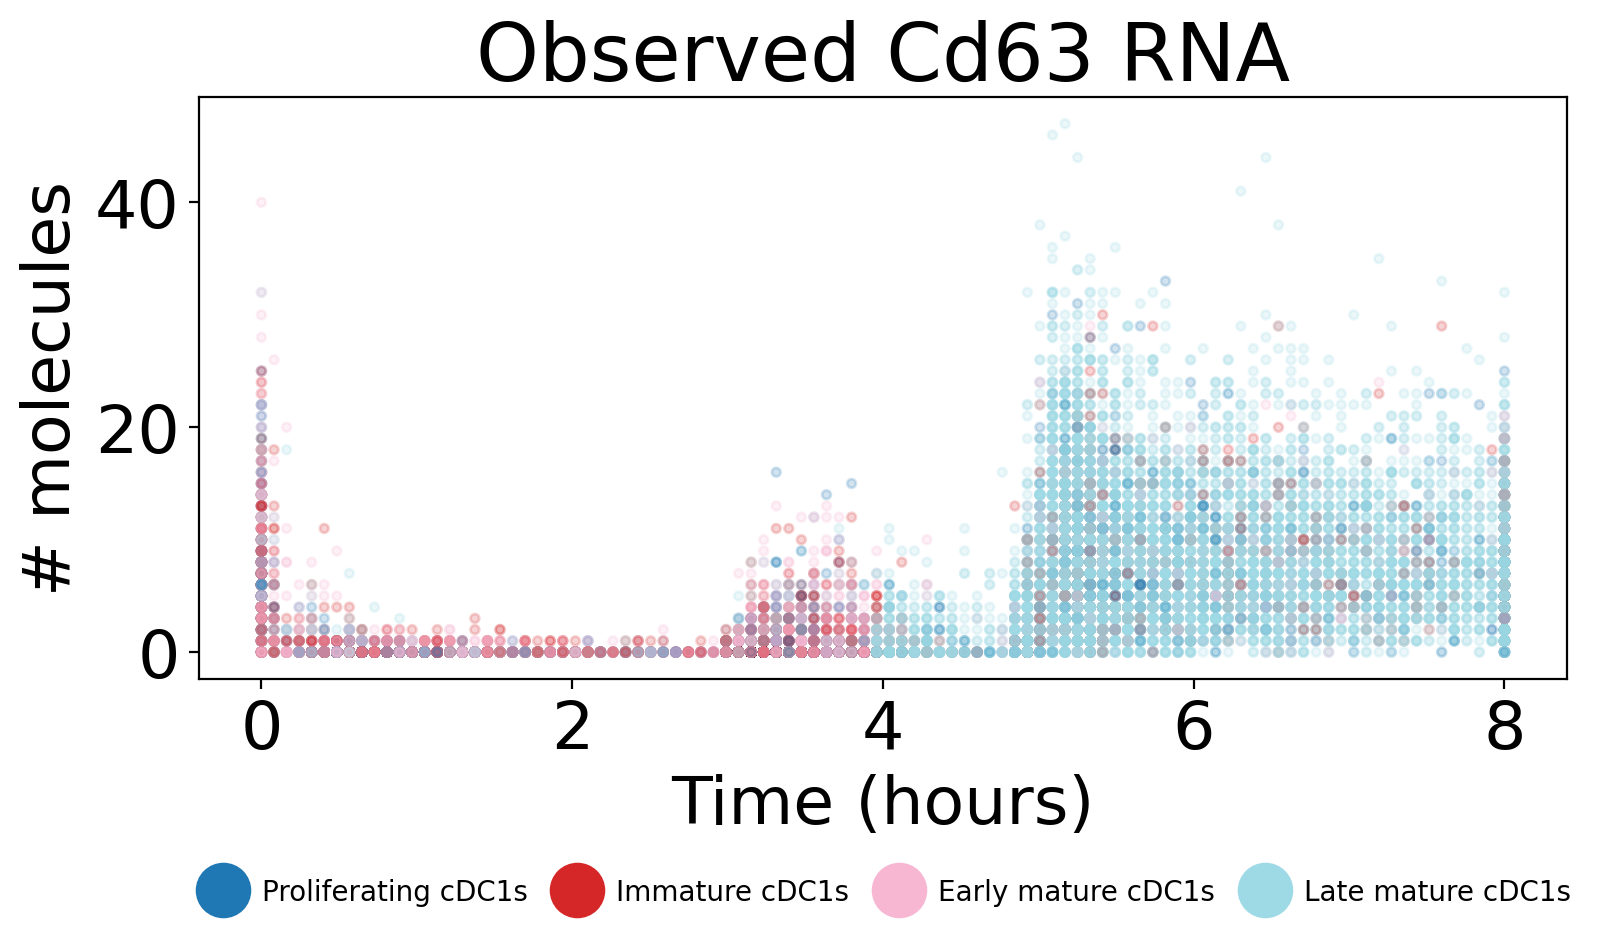

/tmp/ipykernel_4061452/1601259638.py:64: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped


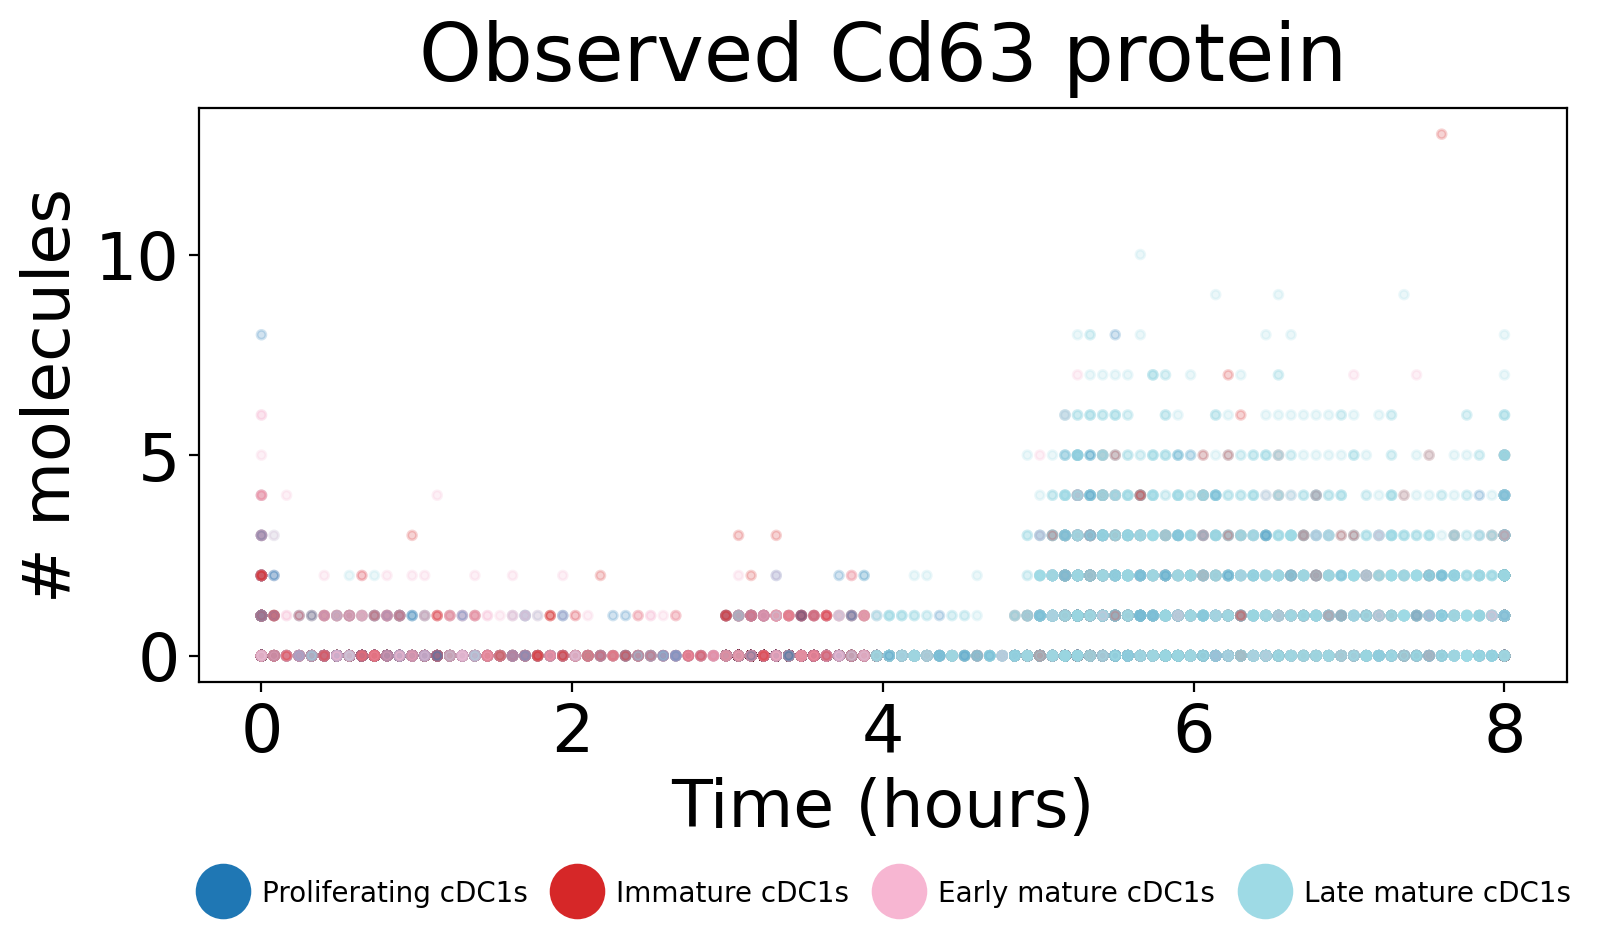

In [295]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- RNA ---
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)

ax.scatter(t_per_cell, expr_RNA_ordered[gene], c=codes, cmap=cmap, s=10, alpha=0.2)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))   # smaller legend markers
    for i, lbl in enumerate(labels)
]

leg = ax.legend(
    handles=handles,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),  # x centered; negative y puts it below
    ncol=5,                       # adjust based on how many clusters you have
    frameon=False,
    fontsize=10,                   # smaller legend text
    handletextpad=0.4,
    columnspacing=0.8
)

ax.set_title(f"Observed {gene} RNA")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")

# make room at the bottom for the legend
fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped
plt.show()

# --- Protein ---
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
ax.scatter(t_per_cell, expr_ADT_ordered[prot], c=codes, cmap=cmap, s=10, alpha=0.2)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))   # smaller legend markers
    for i, lbl in enumerate(labels)
]

leg = ax.legend(
    handles=handles,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),  # x centered; negative y puts it below
    ncol=5,                       # adjust based on how many clusters you have
    frameon=False,
    fontsize=10,                   # smaller legend text
    handletextpad=0.4,
    columnspacing=0.8
)

ax.set_title(f"Observed {gene} protein", pad=10)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")

# make room at the bottom for the legend
fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped
plt.show()

/tmp/ipykernel_4061452/1078612927.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


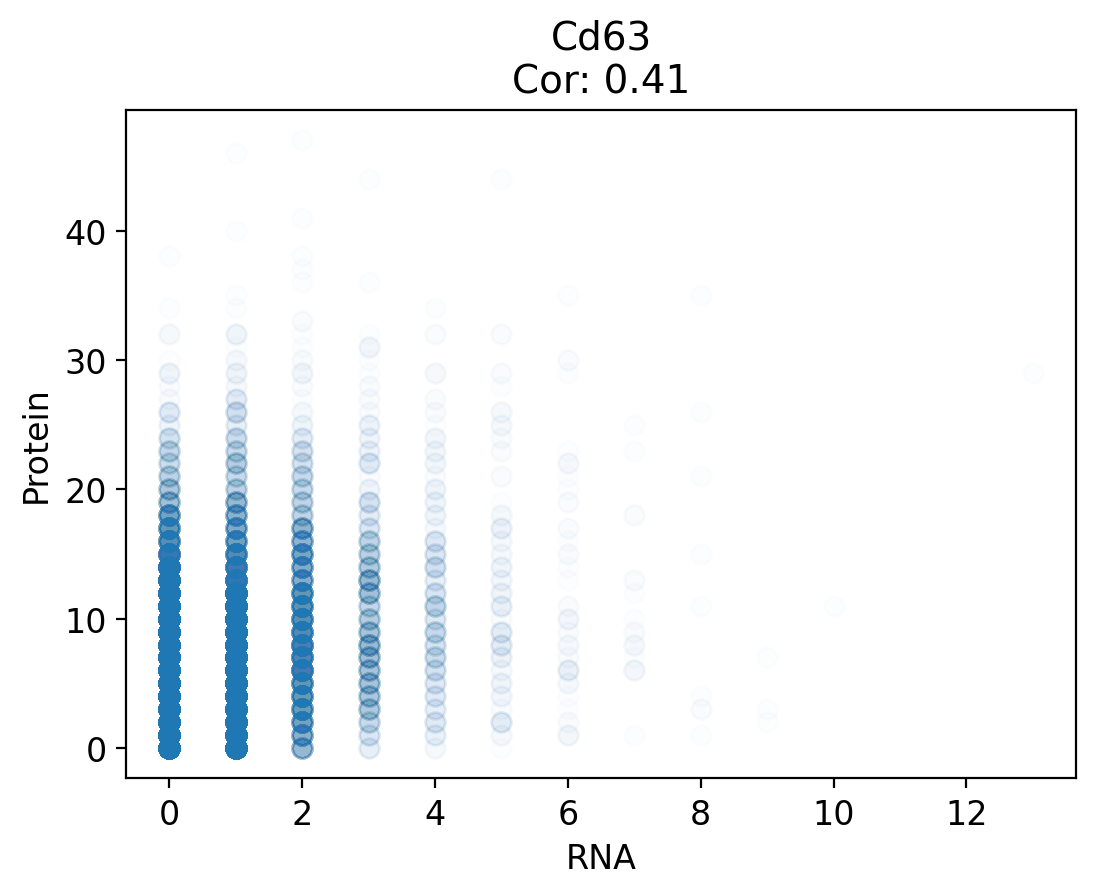

In [296]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)  # bigger + crisper in notebook

ax.scatter(
    expr_ADT_ordered[prot],
    expr_RNA_ordered[gene],
    alpha=0.01,
    s=50
)

ax.set_title(f"{gene}\nCor: {np.round(orig_corr['Cor'].iloc[i], 2)}", fontsize=14)
ax.set_xlabel("RNA", fontsize=12)
ax.set_ylabel("Protein", fontsize=12)
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()


/tmp/ipykernel_4061452/1207169665.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


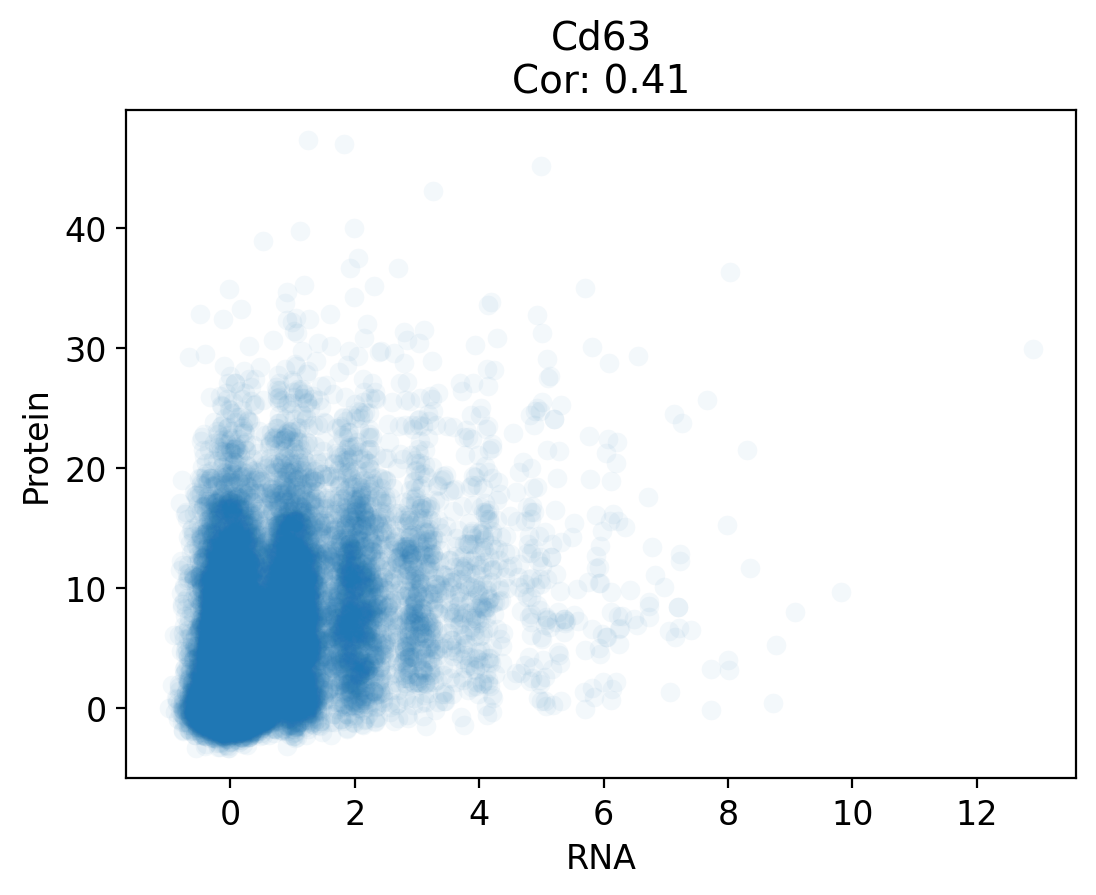

In [297]:
import numpy as np
import matplotlib.pyplot as plt

x = expr_ADT_ordered[prot].to_numpy()
y = expr_RNA_ordered[gene].to_numpy()

rng = np.random.default_rng(0)  # reproducible
jx = 0.02 * (np.nanmax(x) - np.nanmin(x))   # 0.2% of x-range
jy = 0.02 * (np.nanmax(y) - np.nanmin(y))   # 0.2% of y-range

xj = x + rng.normal(0, jx, size=x.shape)
yj = y + rng.normal(0, jy, size=y.shape)

fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
ax.scatter(xj, yj, alpha=0.05, s=50, linewidths=0)

ax.set_title(f"{gene}\nCor: {np.round(orig_corr['Cor'].iloc[i], 2)}", fontsize=14)
ax.set_xlabel("RNA", fontsize=12)
ax.set_ylabel("Protein", fontsize=12)
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()


## Plot observed vs. imputed RNA

In [143]:
# # Plot distribution observed vs. imputed RNA

# plt.hist(expr_RNA_ordered[gene], label="Observed");
# plt.hist(expr_ADT_imputed_ordered[gene], label="Imputed", alpha=0.5);
# plt.legend()


/tmp/ipykernel_4061452/2172103307.py:32: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped


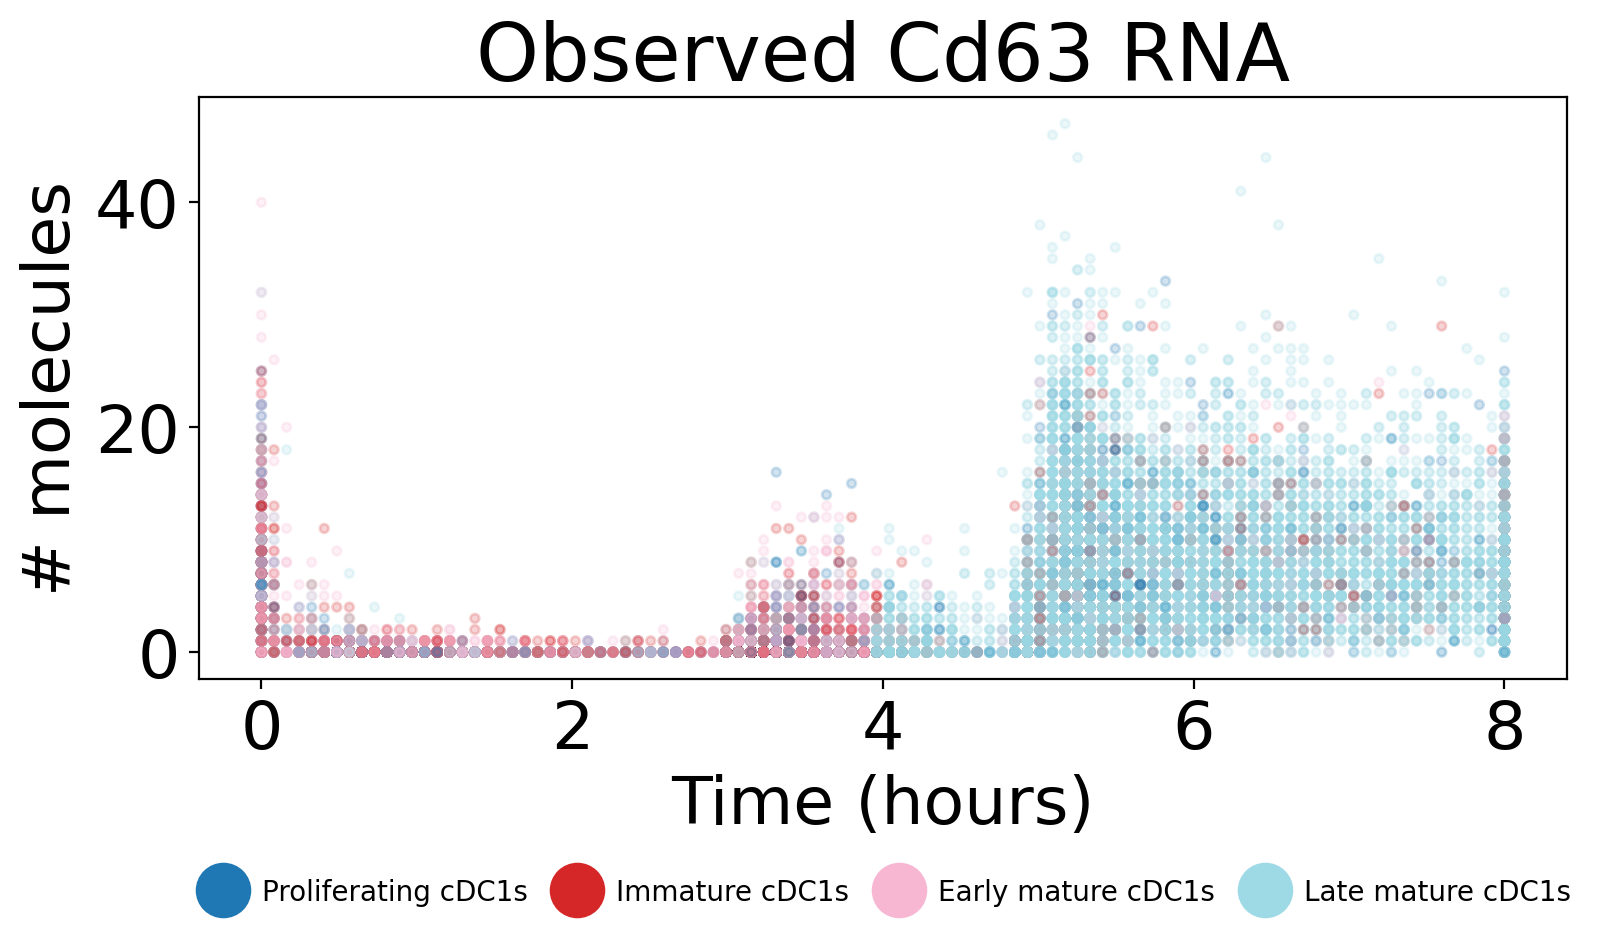

In [298]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- RNA ---
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
ax.scatter(t_per_cell, expr_RNA_ordered[gene], c=codes, cmap=cmap, s=10, alpha=0.2)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))   # smaller legend markers
    for i, lbl in enumerate(labels)
]

leg = ax.legend(
    handles=handles,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),  # x centered; negative y puts it below
    ncol=5,                       # adjust based on how many clusters you have
    frameon=False,
    fontsize=10,                   # smaller legend text
    handletextpad=0.4,
    columnspacing=0.8
)

ax.set_title(f"Observed {gene} RNA")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")

# make room at the bottom for the legend
fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped
plt.show()

/tmp/ipykernel_4061452/4284528605.py:45: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)


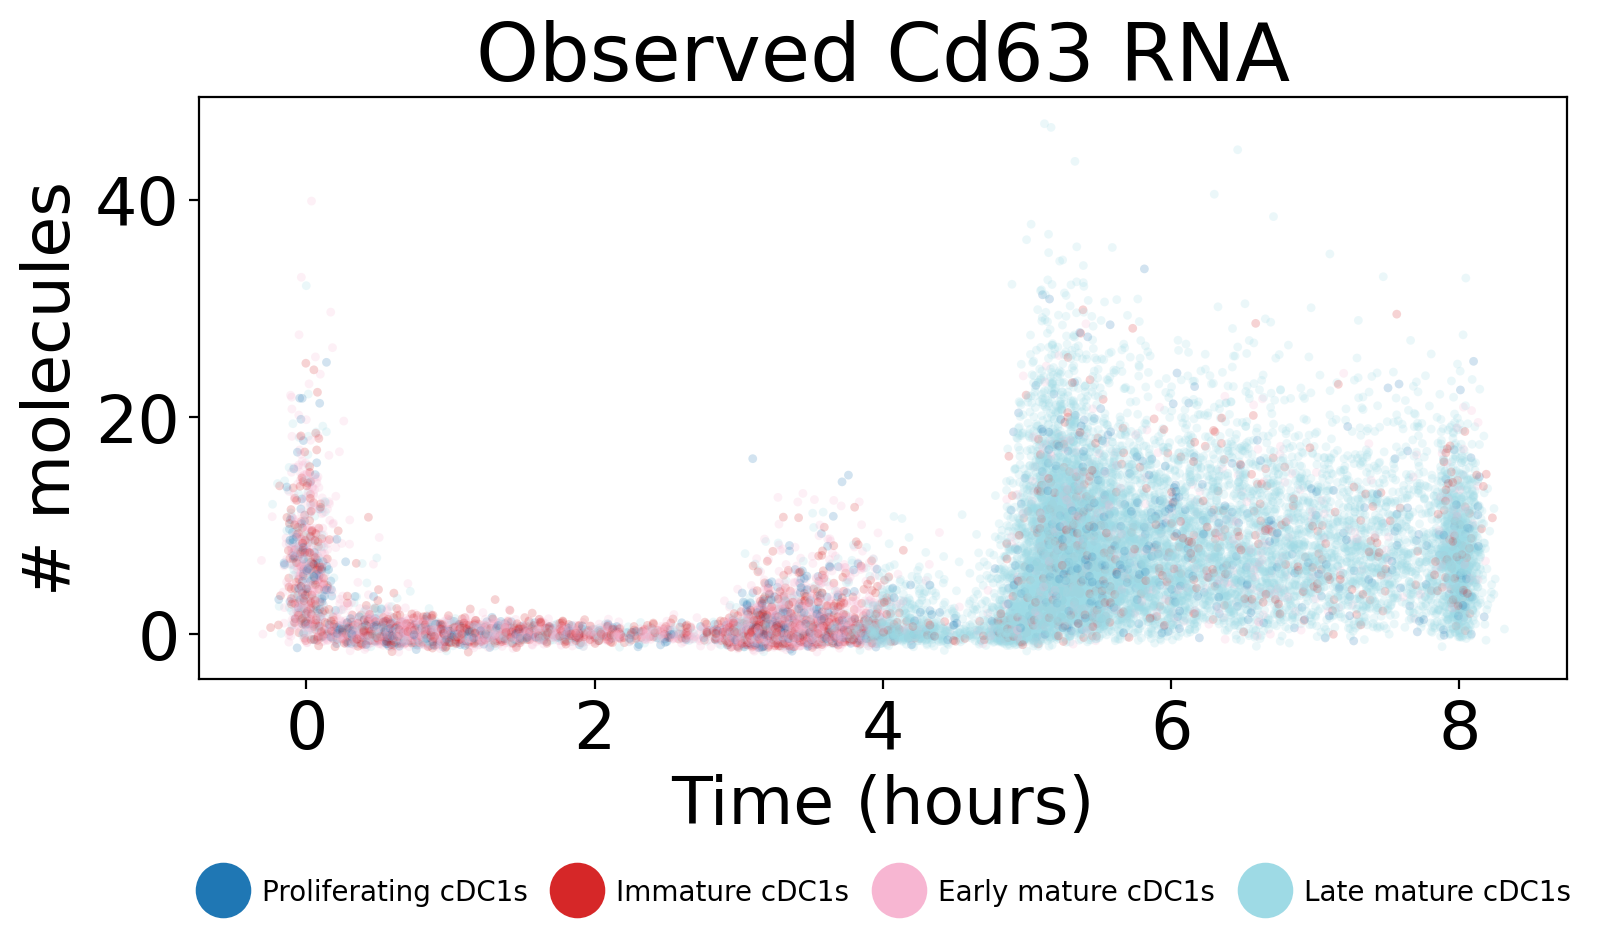

In [299]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x = np.asarray(t_per_cell)
y = np.asarray(expr_RNA_ordered[gene])

rng = np.random.default_rng(0)  # reproducible

# Jitter strengths (tune these)
jx = 0.01 * (np.nanmax(x) - np.nanmin(x))  # 1% of x-range
jy = 0.01 * (np.nanmax(y) - np.nanmin(y))  # 1% of y-range

xj = x + rng.normal(0, jx, size=x.shape)
yj = y + rng.normal(0, jy, size=y.shape)

# --- RNA ---
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)

ax.scatter(xj, yj, c=codes, cmap=cmap, s=10, alpha=0.2, linewidths=0)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))
    for i, lbl in enumerate(labels)
]

ax.legend(
    handles=handles,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=5,
    frameon=False,
    fontsize=10,
    handletextpad=0.4,
    columnspacing=0.8
)

ax.set_title(f"Observed {gene} RNA")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")

fig.subplots_adjust(bottom=0.30)
plt.show()


In [ ]:
# # Plot reconstructed RNA for some cells

# ax.scatter(xj, yj, c=codes, cmap=cmap, s=10, alpha=0.2, linewidths=0)

/tmp/ipykernel_4061452/480487266.py:41: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


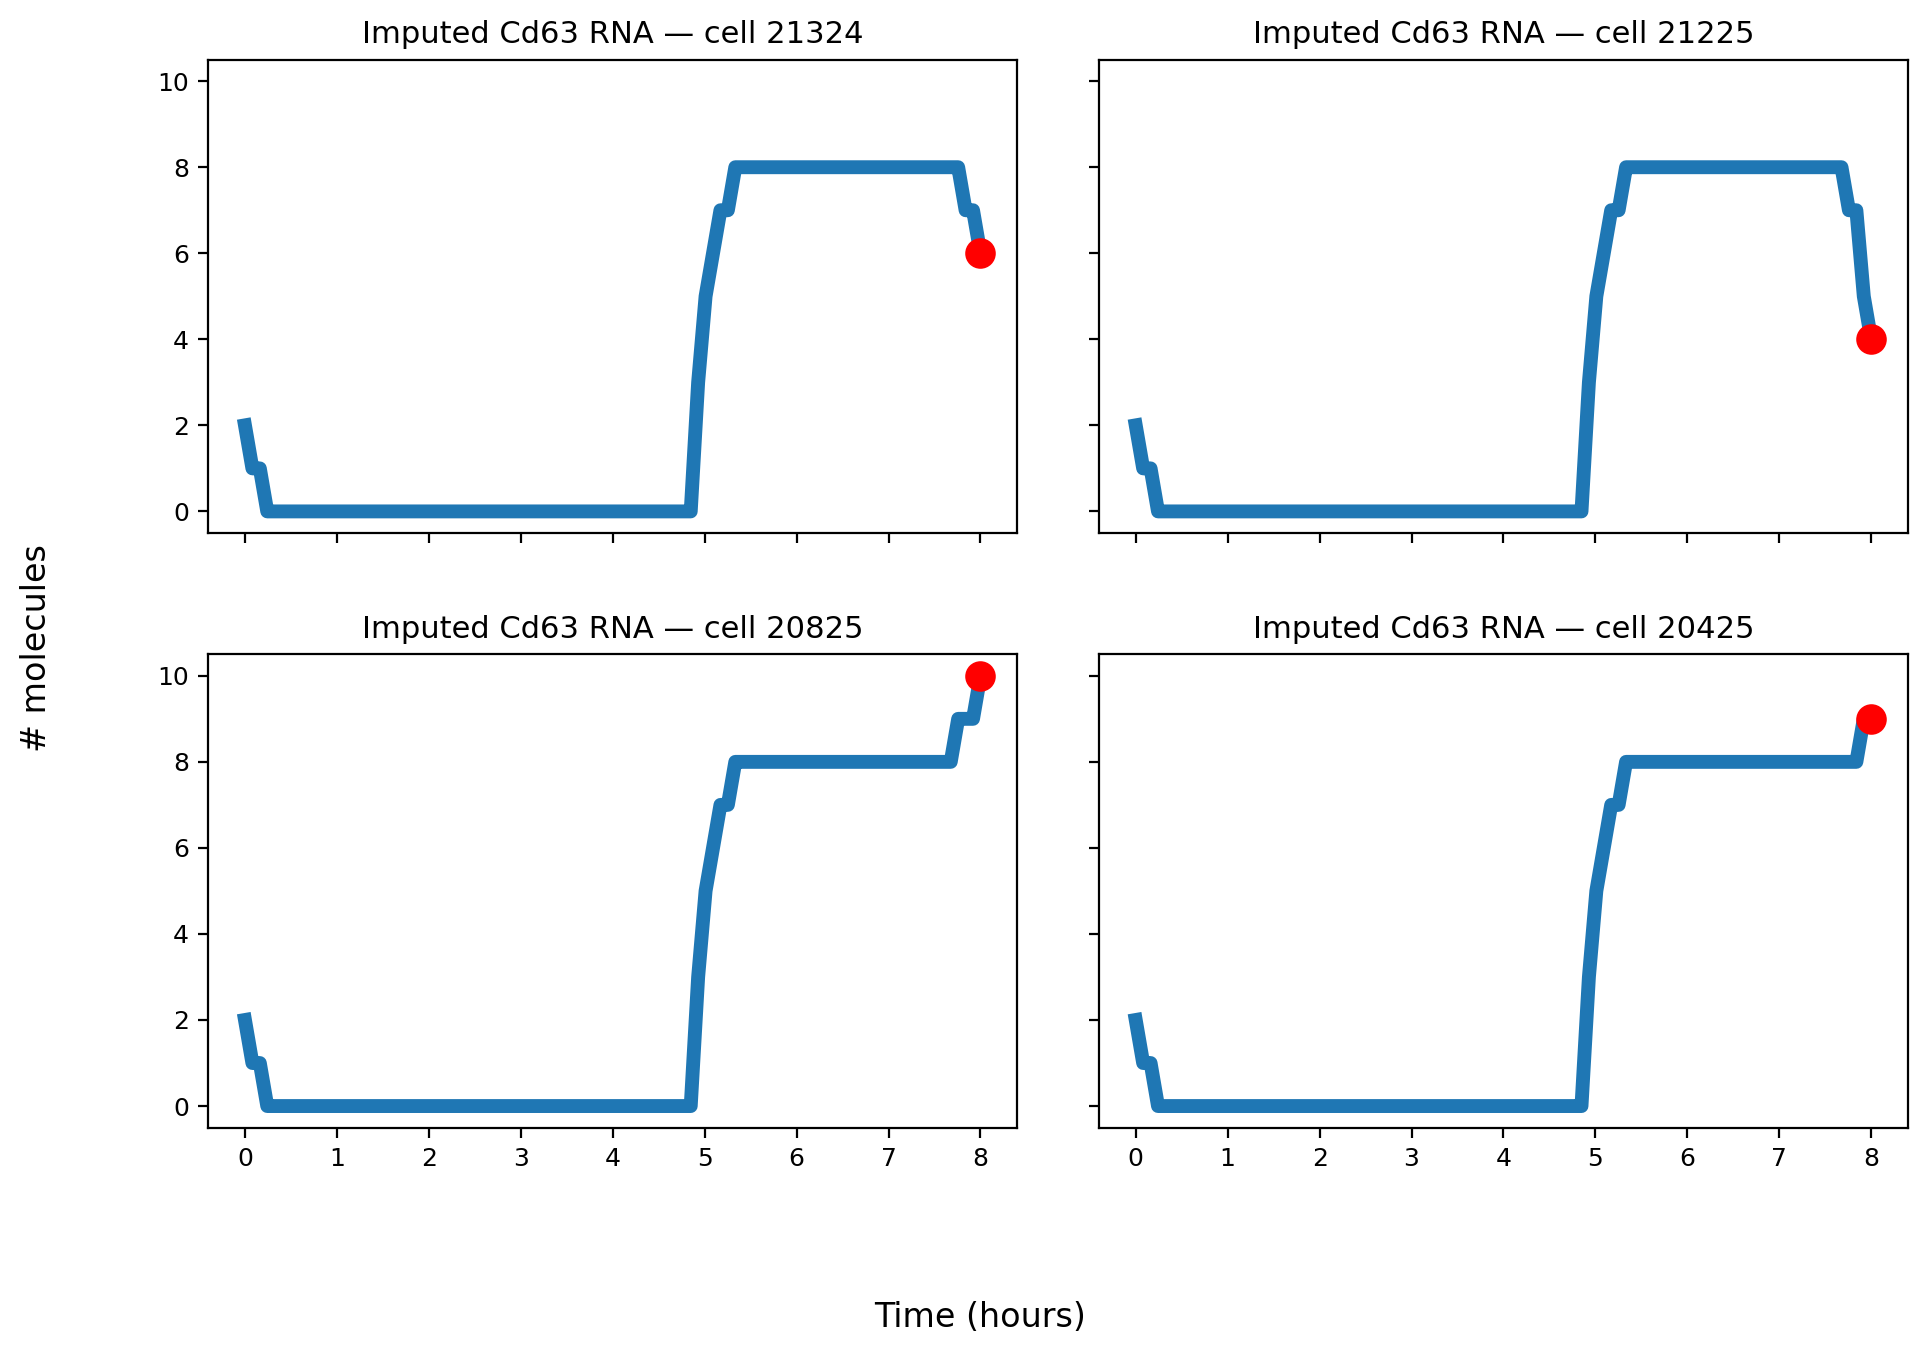

In [300]:
import numpy as np
import matplotlib.pyplot as plt

idxs = (-1, -100, -500, -900)  # up to 4 for a 2x2 grid

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),   # (width, height) in inches
    dpi=200,
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to length-4 array of Axes
n_cells = X_bw_ordered.shape[0]

for ax, idx in zip(axes, idxs):
    valid = np.where(X_bw_ordered[idx, :] > -1)[0]
    if len(valid) == 0:
        ax.set_title(f"idx {idx}: no valid points")
        continue

    start_idx = valid[-1] + 1
    ax.plot(t[:start_idx], X_bw_ordered[idx, :start_idx], linewidth=5)

    # optional: highlight last valid point
    k = start_idx - 1
    ax.scatter(t[k], X_bw_ordered[idx, k], c="red", s=100, zorder=5)

    cell_idx = idx % n_cells
    ax.set_title(f"Imputed {gene} RNA — cell {cell_idx}", fontsize=11)
    ax.tick_params(axis="both", labelsize=9)

# If you have fewer than 4 idxs, turn off unused panels
for ax in axes[len(idxs):]:
    ax.axis("off")

# shared labels (avoid repeating)
fig.supxlabel("Time (hours)", fontsize=12)
fig.supylabel("# molecules", fontsize=12)

fig.tight_layout()
plt.show()


/tmp/ipykernel_4061452/920582333.py:56: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


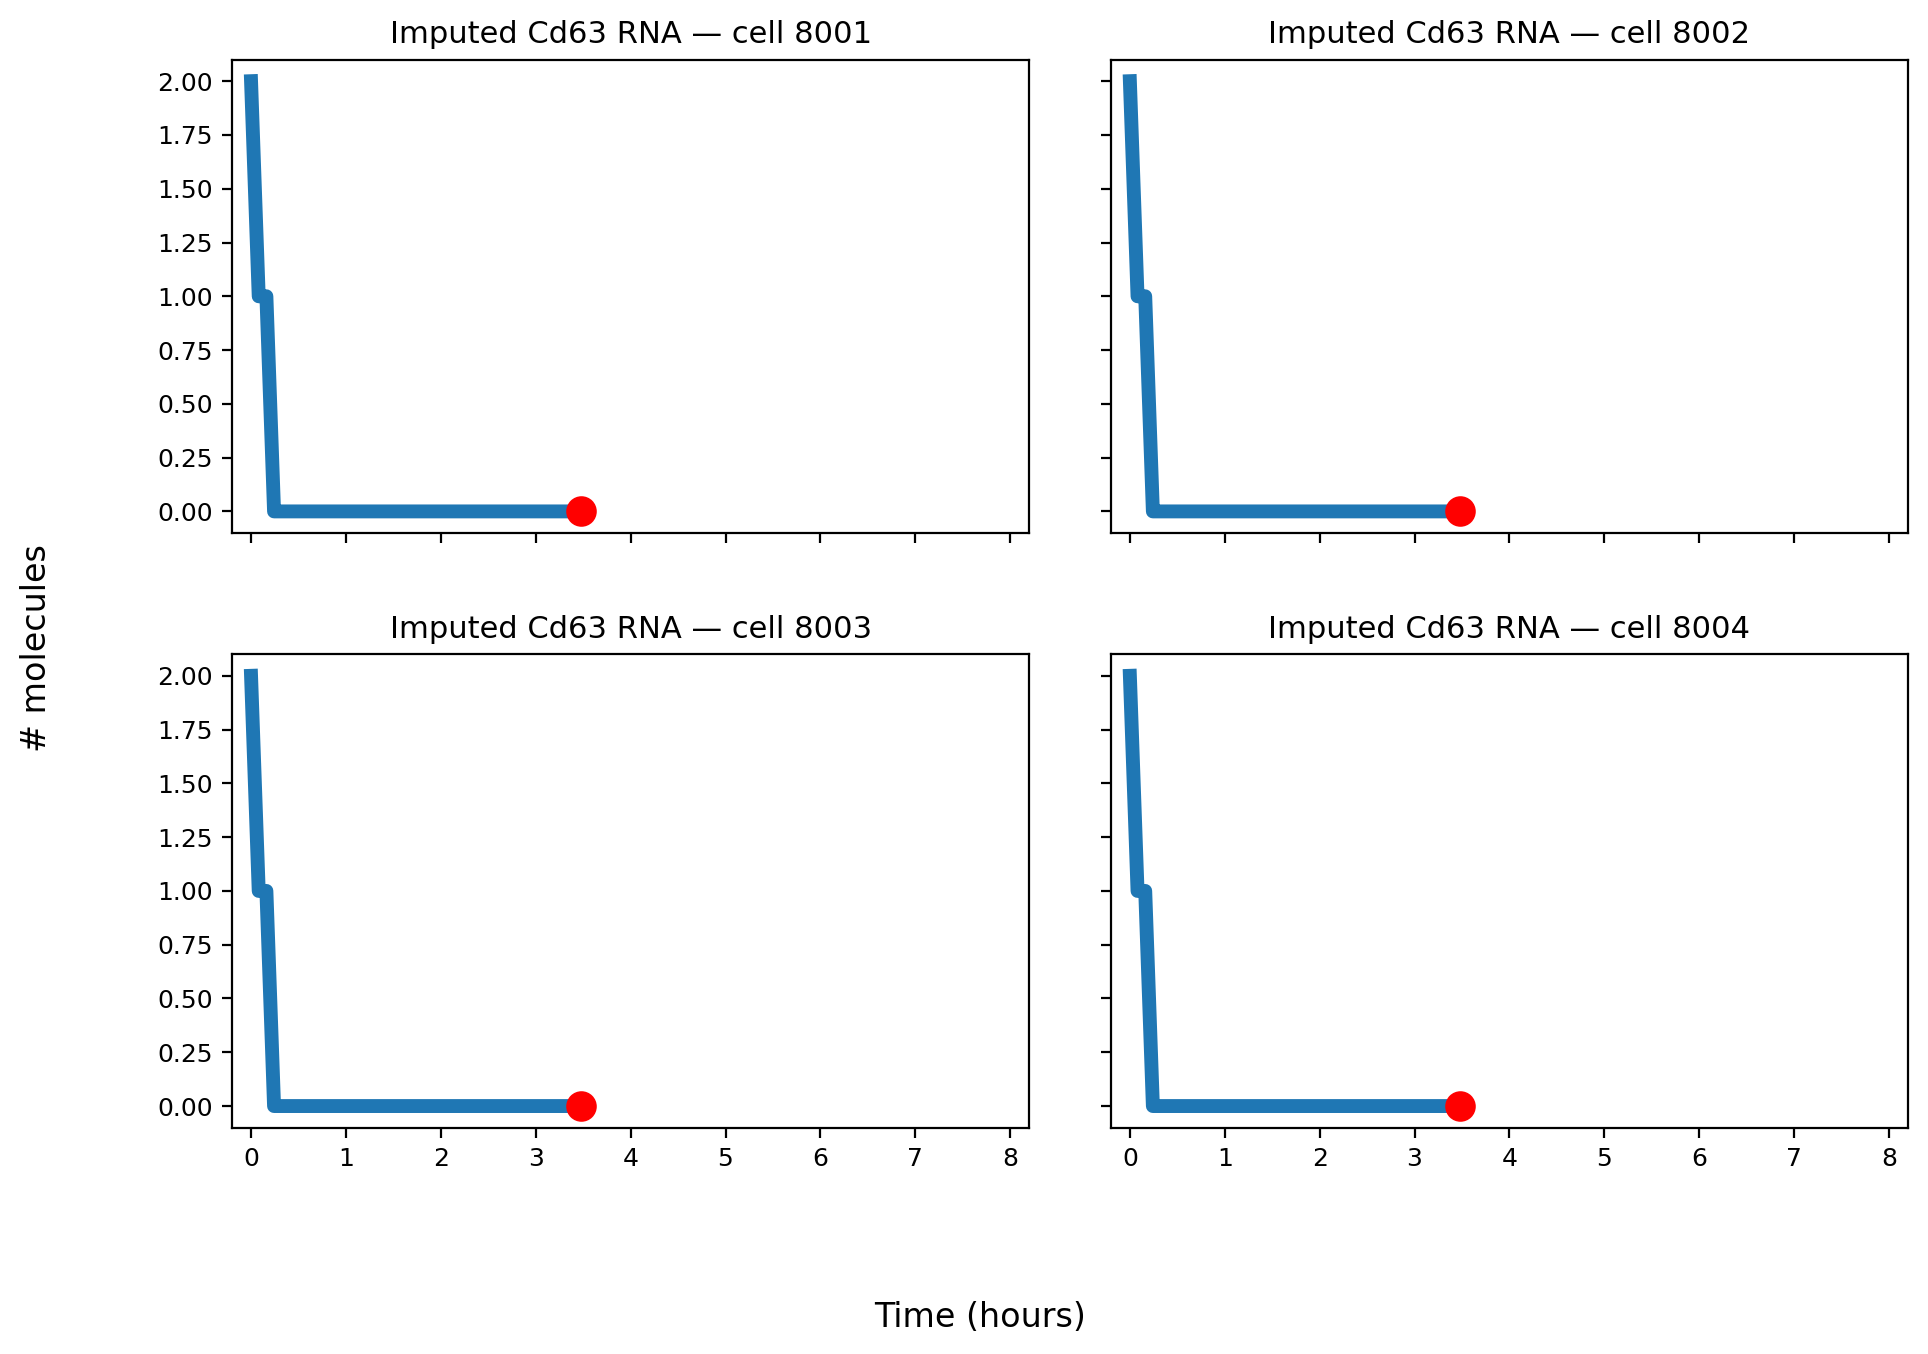

In [301]:
import numpy as np
import matplotlib.pyplot as plt

idxs = (8001, 8002, 8003, 8004)  # up to 4 for a 2x2 grid

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),   # (width, height) in inches
    dpi=200,
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to length-4 array of Axes
n_cells = X_bw_ordered.shape[0]

for ax, idx in zip(axes, idxs):
    valid = np.where(X_bw_ordered[idx, :] > -1)[0]
    if len(valid) == 0:
        ax.set_title(f"idx {idx}: no valid points", fontsize=11)
        continue

    start_idx = valid[-1] + 1

    # line
    ax.plot(
        t[:start_idx],
        X_bw_ordered[idx, :start_idx],
        linewidth=5
    )

    # highlight last valid point (red)
    k = start_idx - 1
    ax.scatter(
        t[k],
        X_bw_ordered[idx, k],
        c="red",
        s=100,
        zorder=5
    )

    cell_idx = idx % n_cells
    ax.set_title(f"Imputed {gene} RNA — cell {cell_idx}", fontsize=11)
    ax.tick_params(axis="both", labelsize=9)

    # optional: enforce same x-limits everywhere
    ax.set_xlim((-0.2, 8.2))

# If you have fewer than 4 idxs, turn off unused panels
for ax in axes[len(idxs):]:
    ax.axis("off")

# shared labels (avoid repeating)
fig.supxlabel("Time (hours)", fontsize=12)
fig.supylabel("# molecules", fontsize=12)

fig.tight_layout()
plt.show()



/tmp/ipykernel_4061452/1835863697.py:56: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


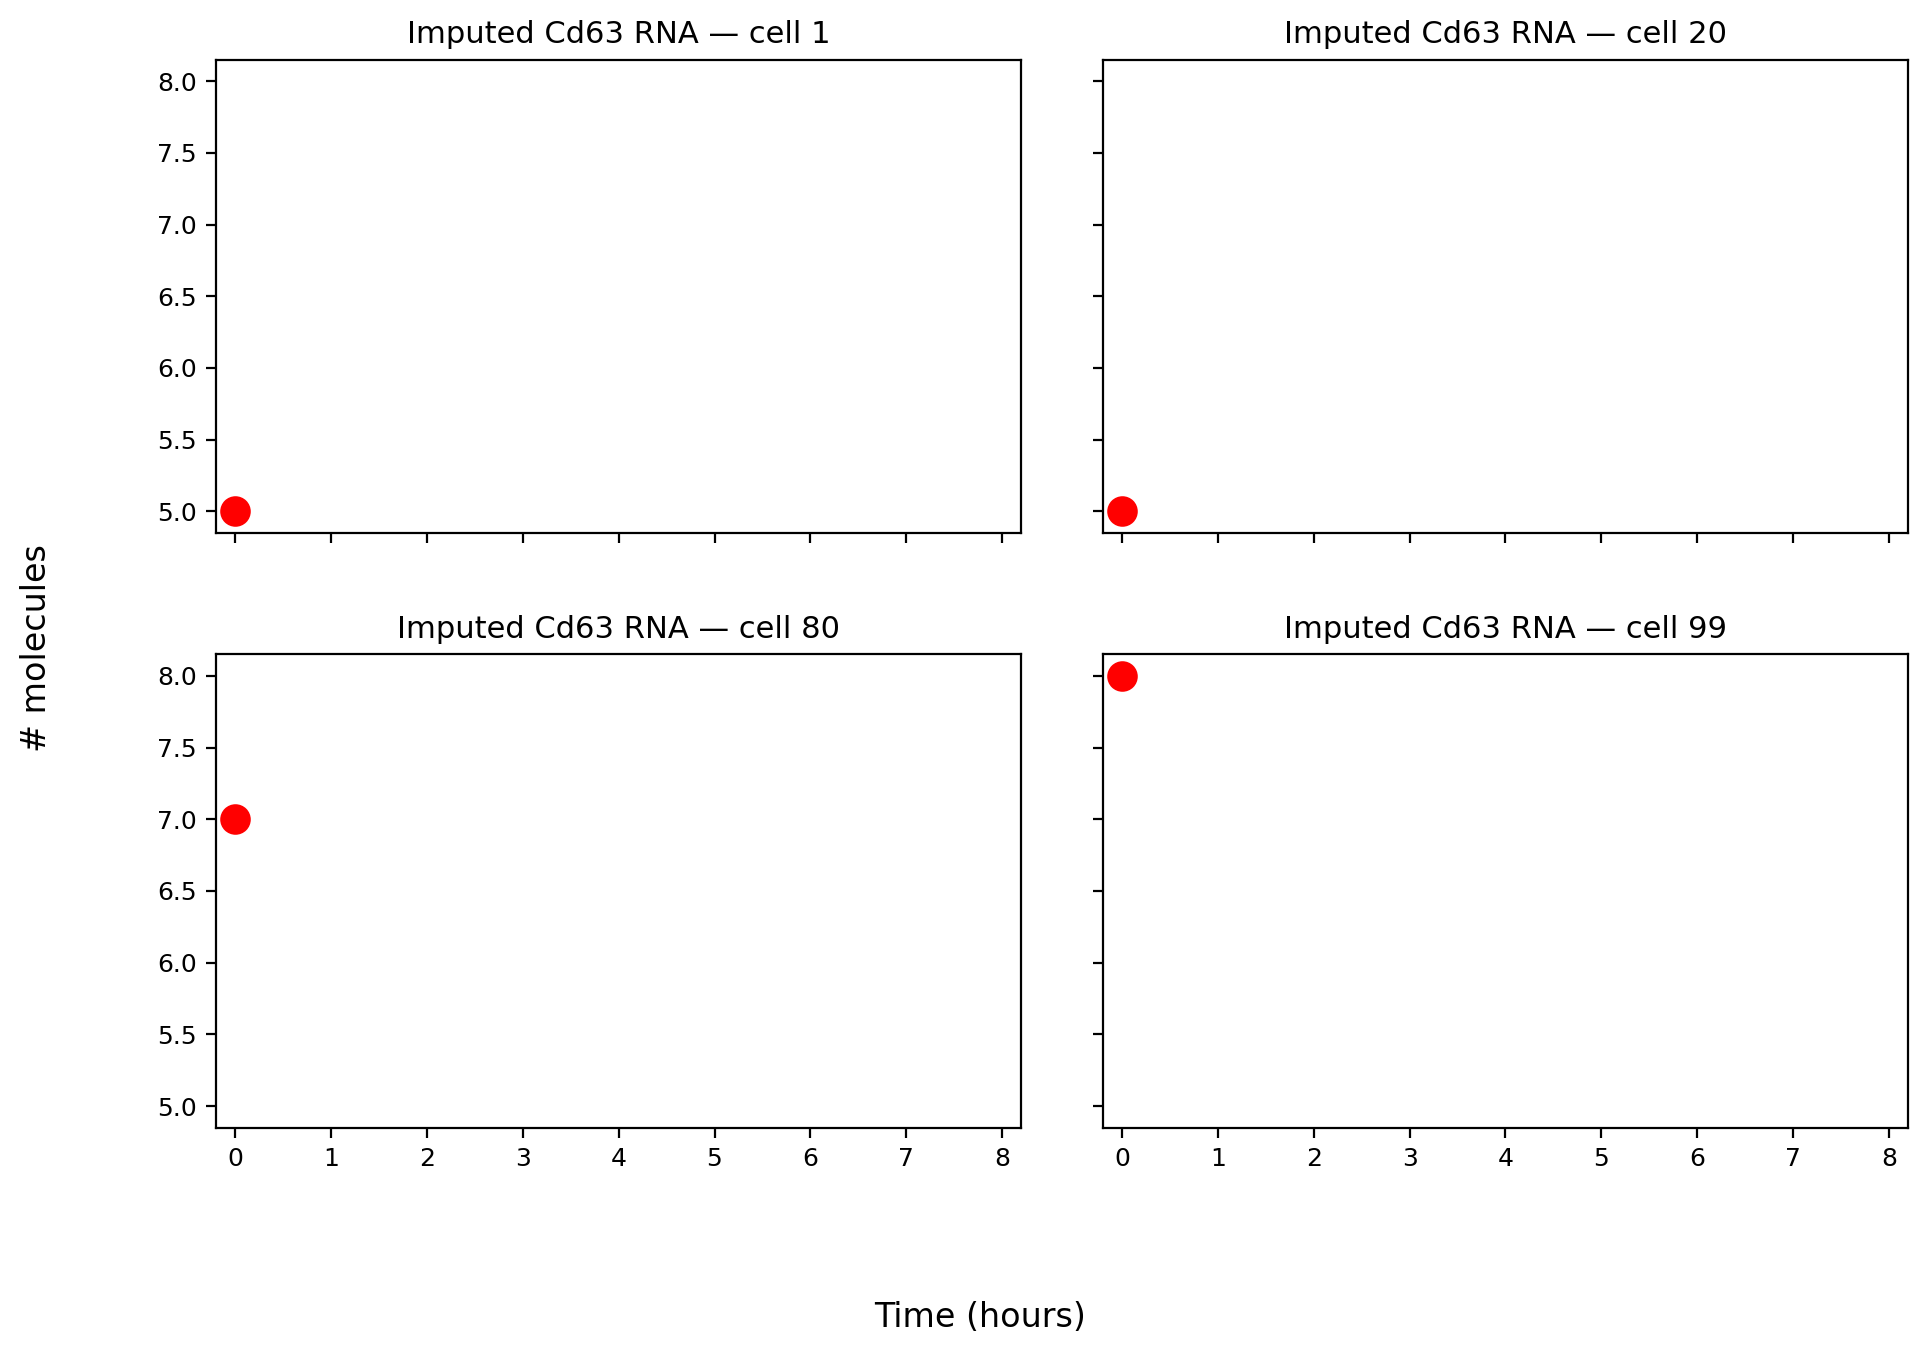

In [302]:
import numpy as np
import matplotlib.pyplot as plt

idxs = (1, 20, 80, 99, 101)  # up to 4 for a 2x2 grid

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),   # (width, height) in inches
    dpi=200,
    sharex=True, sharey=True
)

axes = axes.ravel()  # flatten to length-4 array of Axes
n_cells = X_bw_ordered.shape[0]

for ax, idx in zip(axes, idxs):
    valid = np.where(X_bw_ordered[idx, :] > -1)[0]
    if len(valid) == 0:
        ax.set_title(f"idx {idx}: no valid points", fontsize=11)
        continue

    start_idx = valid[-1] + 1

    # line
    ax.plot(
        t[:start_idx],
        X_bw_ordered[idx, :start_idx],
        linewidth=5
    )

    # highlight last valid point (red)
    k = start_idx - 1
    ax.scatter(
        t[k],
        X_bw_ordered[idx, k],
        c="red",
        s=100,
        zorder=5
    )

    cell_idx = idx % n_cells
    ax.set_title(f"Imputed {gene} RNA — cell {cell_idx}", fontsize=11)
    ax.tick_params(axis="both", labelsize=9)

    # optional: enforce same x-limits everywhere
    ax.set_xlim((-0.2, 8.2))

# If you have fewer than 4 idxs, turn off unused panels
for ax in axes[len(idxs):]:
    ax.axis("off")

# shared labels (avoid repeating)
fig.supxlabel("Time (hours)", fontsize=12)
fig.supylabel("# molecules", fontsize=12)

fig.tight_layout()
plt.show()



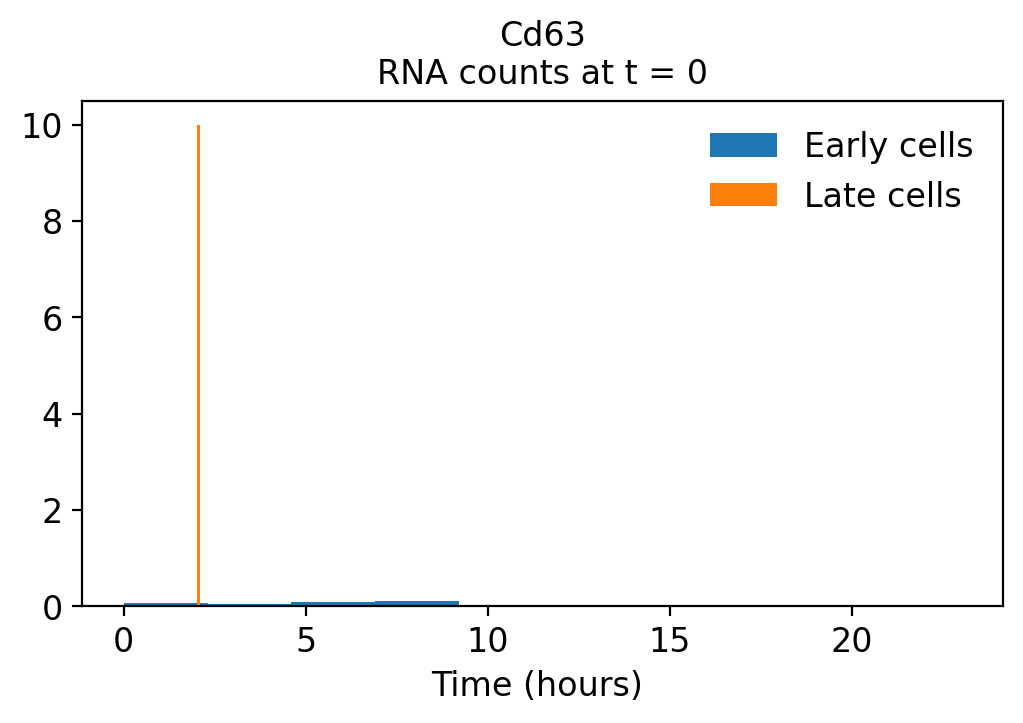

In [305]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.hist(X_bw_ordered[:60, 0], label="Early cells", density=True)
ax.hist(X_bw_ordered[20000:, 0], label="Late cells", density=True)
ax.set_title(f"{gene}\nRNA counts at t = 0", fontsize=12)
ax.set_xlabel("Time (hours) ", fontsize=12)
ax.tick_params(labelsize=12)
# ax.set_xlim((0, 8))
ax.legend(frameon=False, fontsize=12)
plt.show()

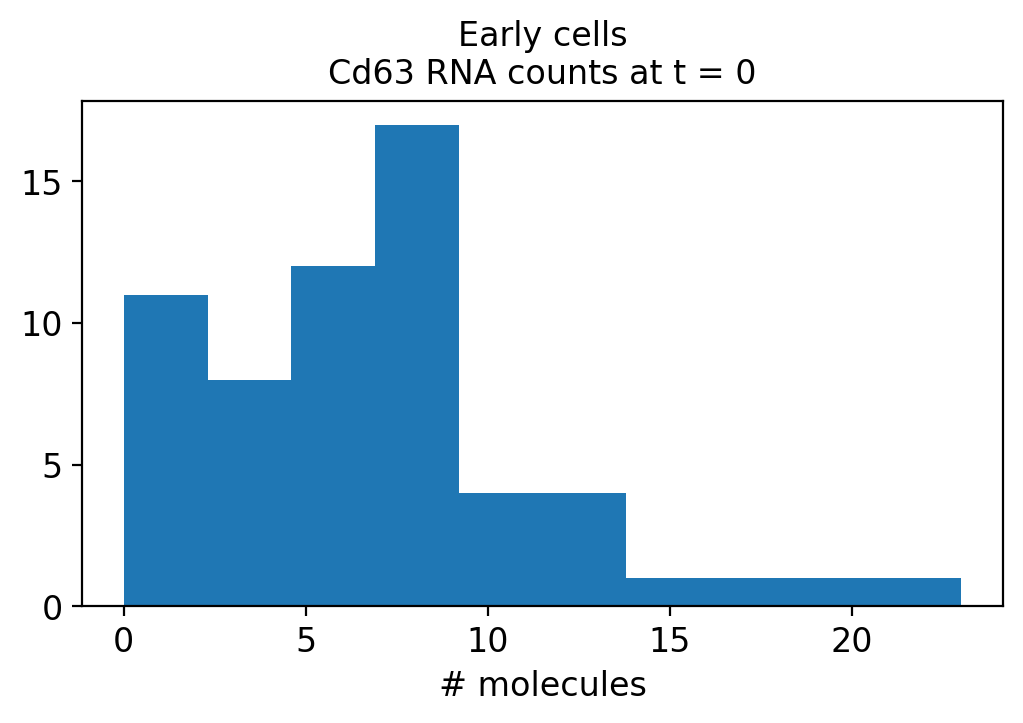

In [306]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.hist(X_bw_ordered[:60, 0])
ax.set_title(f"Early cells\n{gene} RNA counts at t = 0", fontsize=12)
ax.set_xlabel("# molecules", fontsize=12)
ax.tick_params(labelsize=12)
plt.show()

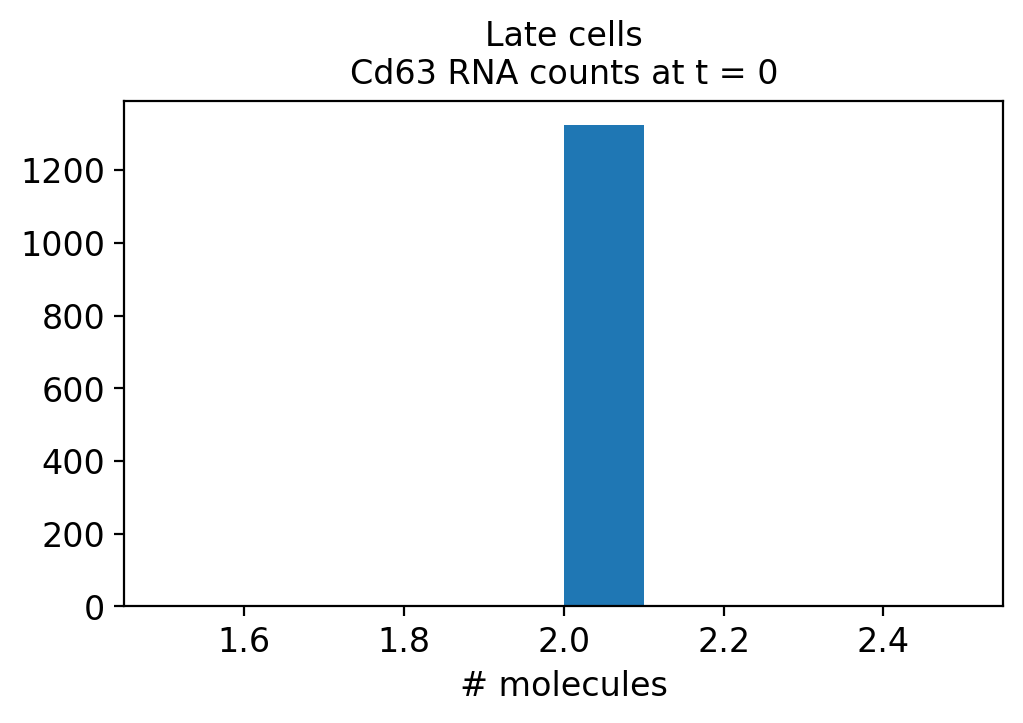

In [307]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.hist(X_bw_ordered[20000:, 0])
ax.set_title(f"Late cells\n{gene} RNA counts at t = 0", fontsize=12)
ax.set_xlabel("Time (hours) ", fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xlabel("# molecules", fontsize=12)
plt.show()

## Plot observed vs. imputed protein

### Replot observed protein

/tmp/ipykernel_4061452/1227946334.py:30: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped


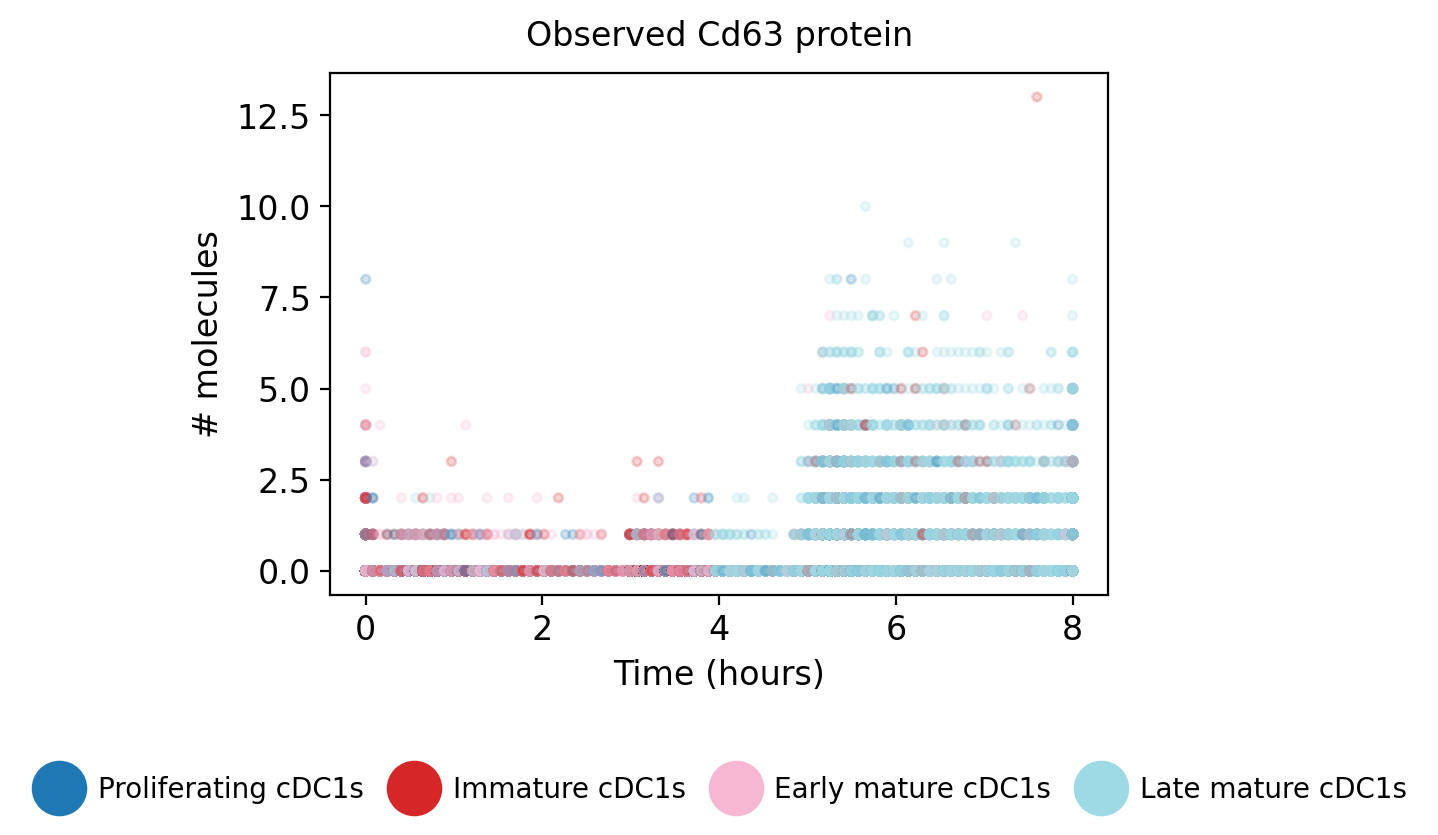

In [308]:
# --- Protein ---
fig, ax = plt.subplots(figsize=(6.5, 4), dpi=200)
ax.scatter(t_per_cell, expr_ADT_ordered[prot], c=codes, cmap=cmap, s=10, alpha=0.2)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))   # smaller legend markers
    for i, lbl in enumerate(labels)
]

leg = ax.legend(
    handles=handles,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),  # x centered; negative y puts it below
    ncol=5,                       # adjust based on how many clusters you have
    frameon=False,
    fontsize=10,                   # smaller legend text
    handletextpad=0.4,
    columnspacing=0.8
)

ax.set_title(f"Observed {gene} protein", pad=10, fontsize=12)
ax.set_xlabel("Time (hours)", fontsize=12)
ax.set_ylabel("# molecules", fontsize=12)
ax.tick_params(labelsize=12)

# make room at the bottom for the legend
fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped
plt.show()

/tmp/ipykernel_4061452/1717400612.py:35: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)


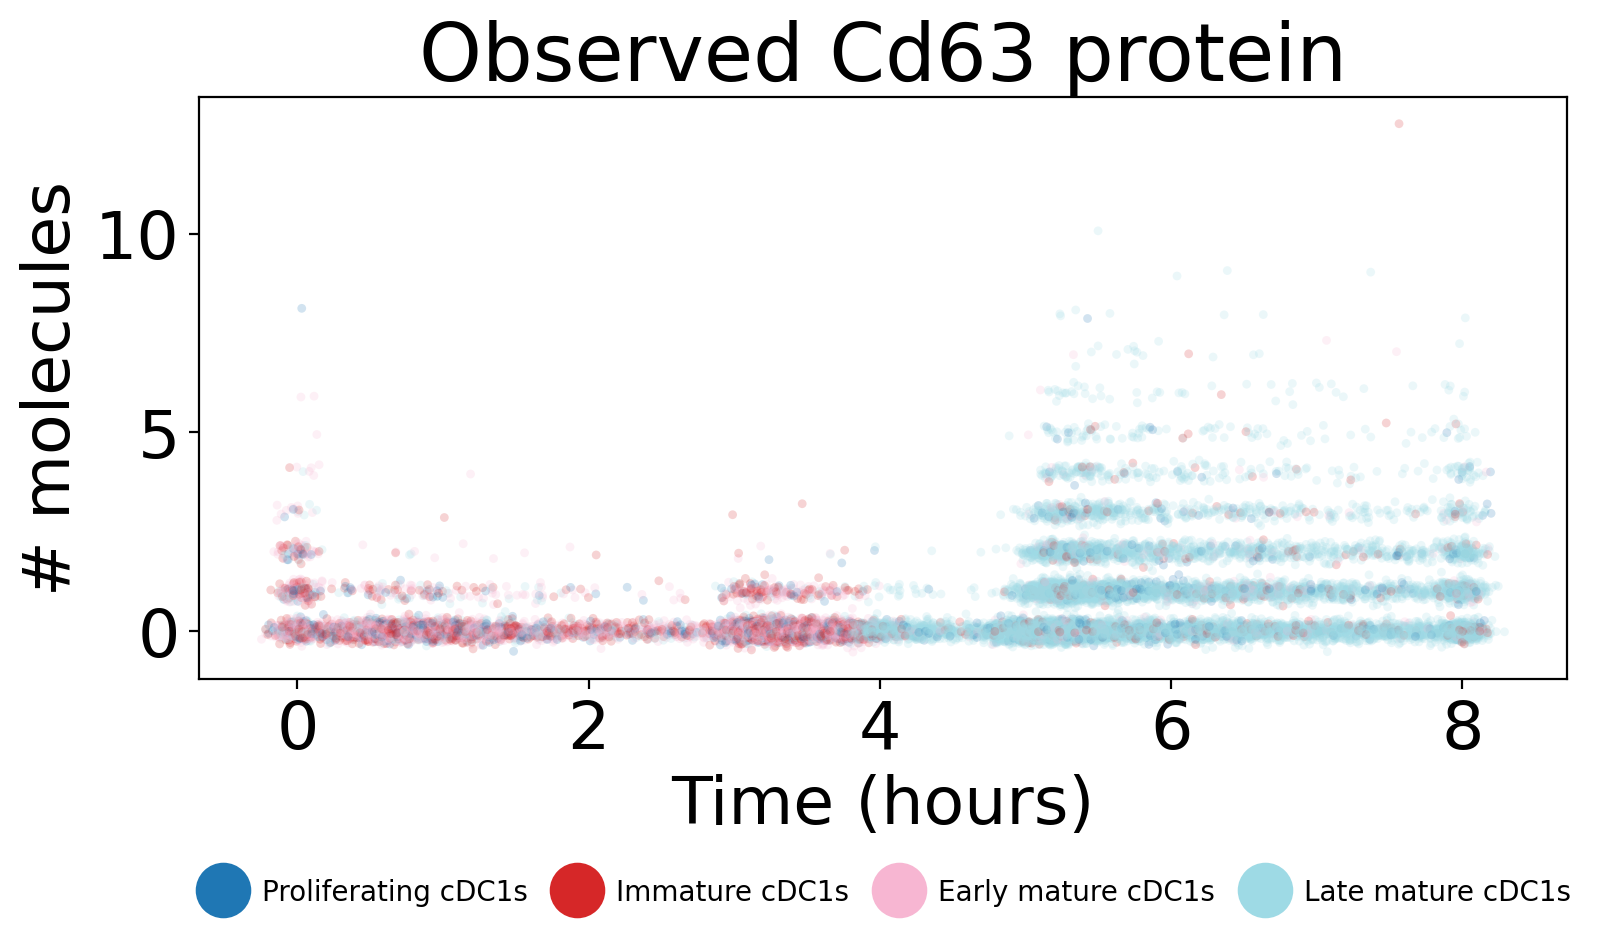

In [309]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Protein ---
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
rng = np.random.default_rng(1)  # different jitter than RNA plot
x = np.asarray(t_per_cell)
y = np.asarray(expr_ADT_ordered[prot])

jx = 0.01 * (np.nanmax(x) - np.nanmin(x))
jy = 0.01 * (np.nanmax(y) - np.nanmin(y))

xj = x + rng.normal(0, jx, size=x.shape)
yj = y + rng.normal(0, jy, size=y.shape)

ax.scatter(xj, yj, c=codes, cmap=cmap, s=10, alpha=0.2, linewidths=0)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))
    for i, lbl in enumerate(labels)
]

ax.legend(handles=handles, title=None, loc="upper center",
          bbox_to_anchor=(0.5, -0.30), ncol=5, frameon=False,
          fontsize=10, handletextpad=0.4, columnspacing=0.8)

ax.set_title(f"Observed {gene} protein")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")


fig.subplots_adjust(bottom=0.30)
plt.show()

### Plot imputed protein

/tmp/ipykernel_4061452/3574818634.py:29: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped


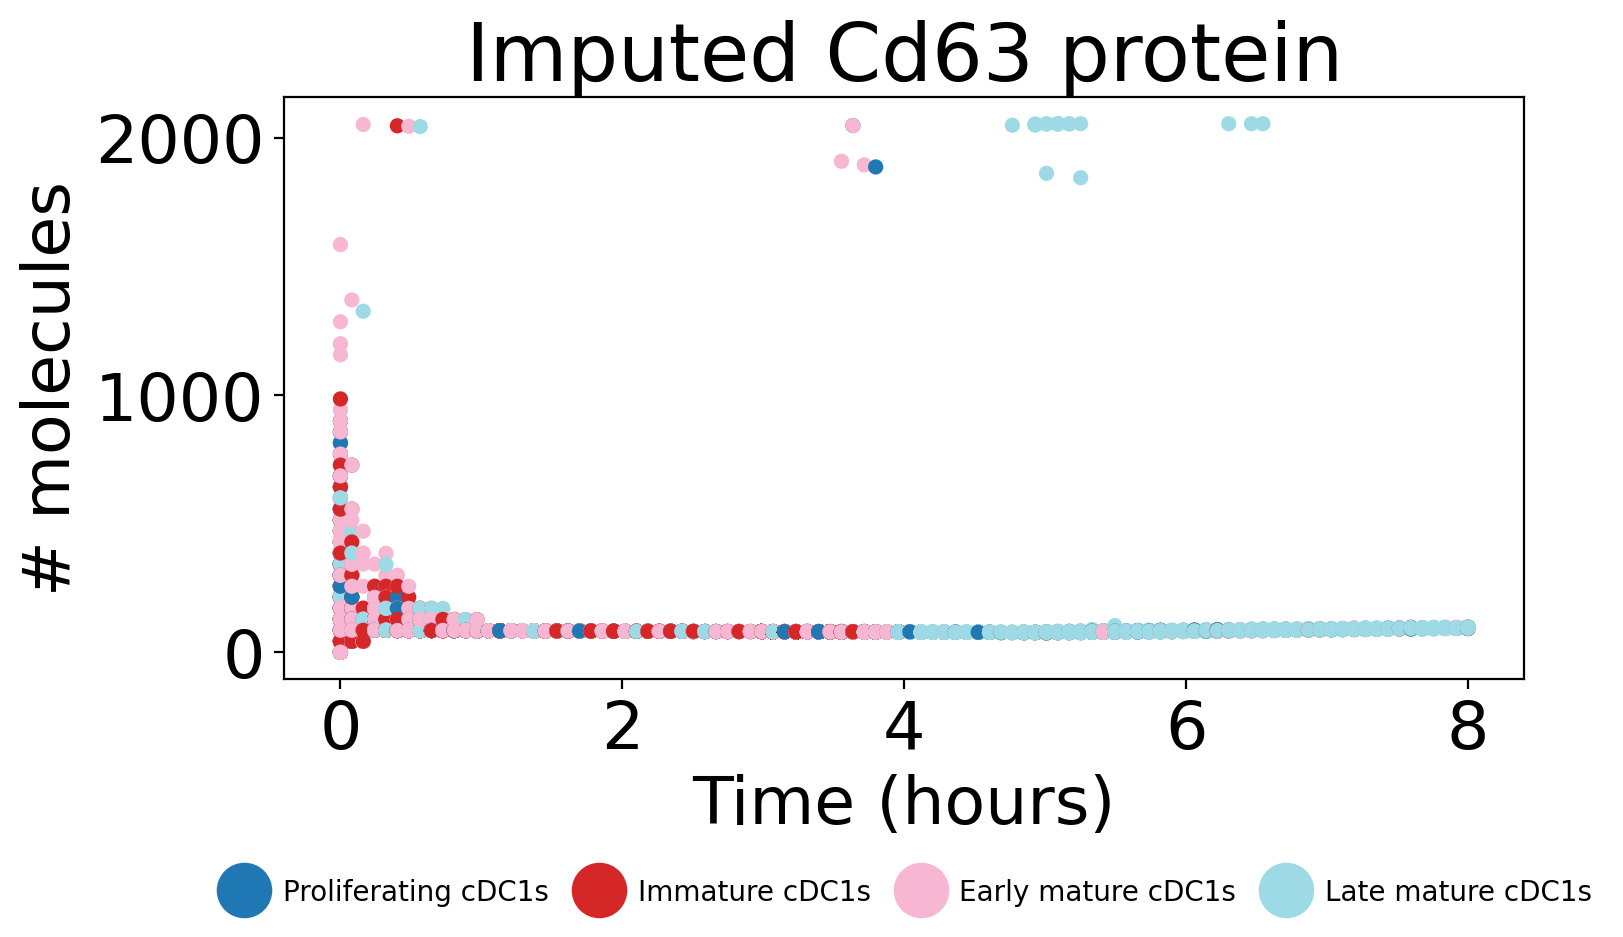

In [310]:
# --- Protein ---
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
ax.scatter(t_per_cell, expr_ADT_imputed_ordered[gene], c=codes, cmap=cmap, s=20, alpha=1)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))   # smaller legend markers
    for i, lbl in enumerate(labels)
]

leg = ax.legend(
    handles=handles,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),  # x centered; negative y puts it below
    ncol=5,                       # adjust based on how many clusters you have
    frameon=False,
    fontsize=10,                   # smaller legend text
    handletextpad=0.4,
    columnspacing=0.8
)

ax.set_title(f"Imputed {gene} protein")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")

# make room at the bottom for the legend
fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped
plt.show()

/tmp/ipykernel_4061452/3345398435.py:36: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)


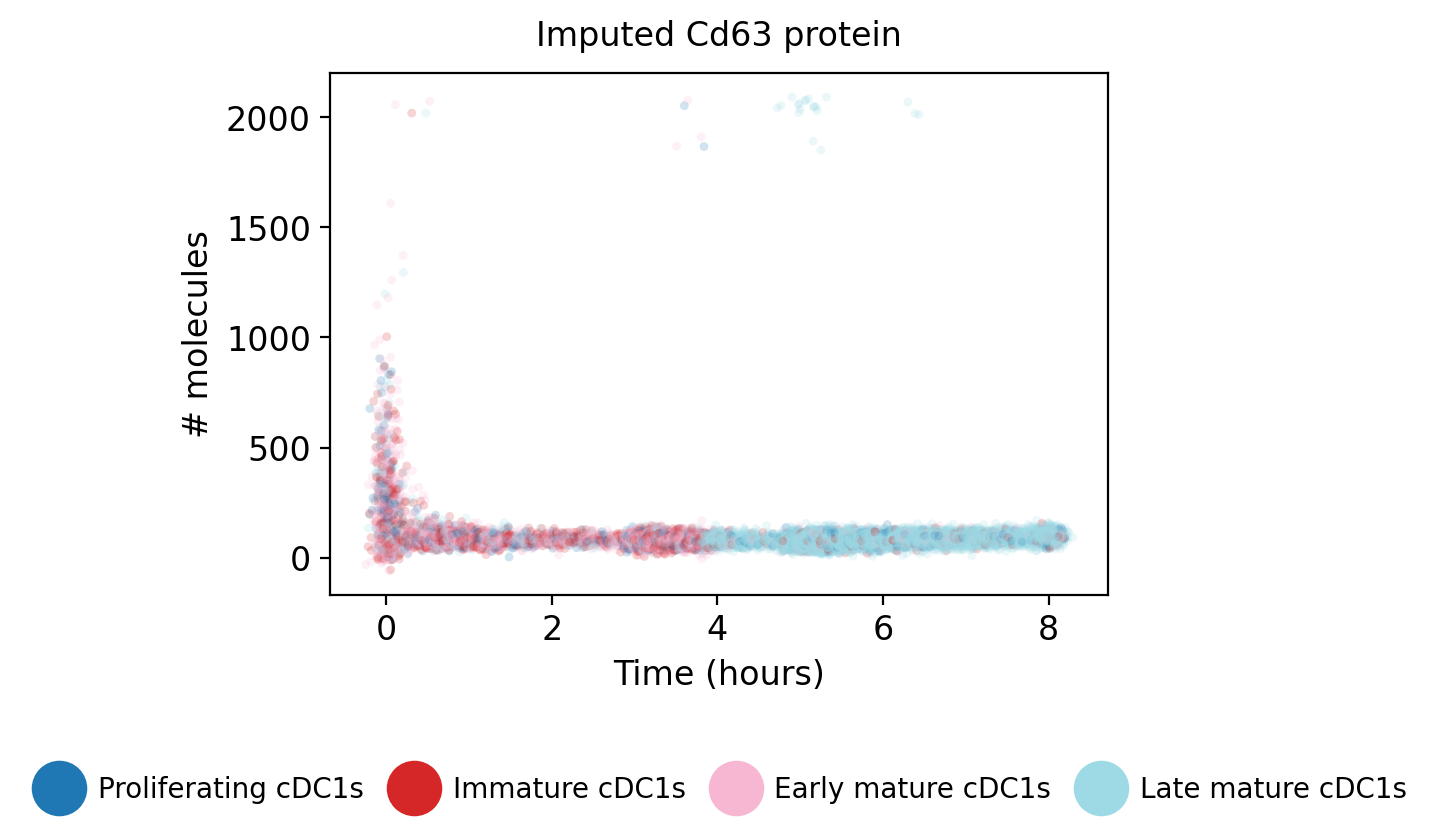

In [311]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Protein ---
fig, ax = plt.subplots(figsize=(6.5, 4), dpi=200)

rng = np.random.default_rng(1)  # different jitter than RNA plot
x = np.asarray(t_per_cell)
y = np.asarray(expr_ADT_imputed_ordered[gene])

jx = 0.01 * (np.nanmax(x) - np.nanmin(x))
jy = 0.01 * (np.nanmax(y) - np.nanmin(y))

xj = x + rng.normal(0, jx, size=x.shape)
yj = y + rng.normal(0, jy, size=y.shape)

ax.scatter(xj, yj, c=codes, cmap=cmap, s=10, alpha=0.2, linewidths=0)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))
    for i, lbl in enumerate(labels)
]

ax.legend(handles=handles, title=None, loc="upper center",
          bbox_to_anchor=(0.5, -0.30), ncol=5, frameon=False,
          fontsize=10, handletextpad=0.4, columnspacing=0.8)

ax.set_title(f"Imputed {gene} protein", pad=10, fontsize=12)
ax.set_xlabel("Time (hours)", fontsize=12)
ax.set_ylabel("# molecules", fontsize=12)
ax.tick_params(labelsize=12)

fig.subplots_adjust(bottom=0.30)
plt.show()

### Zoom in on imputed counts

/tmp/ipykernel_4061452/773079609.py:31: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped


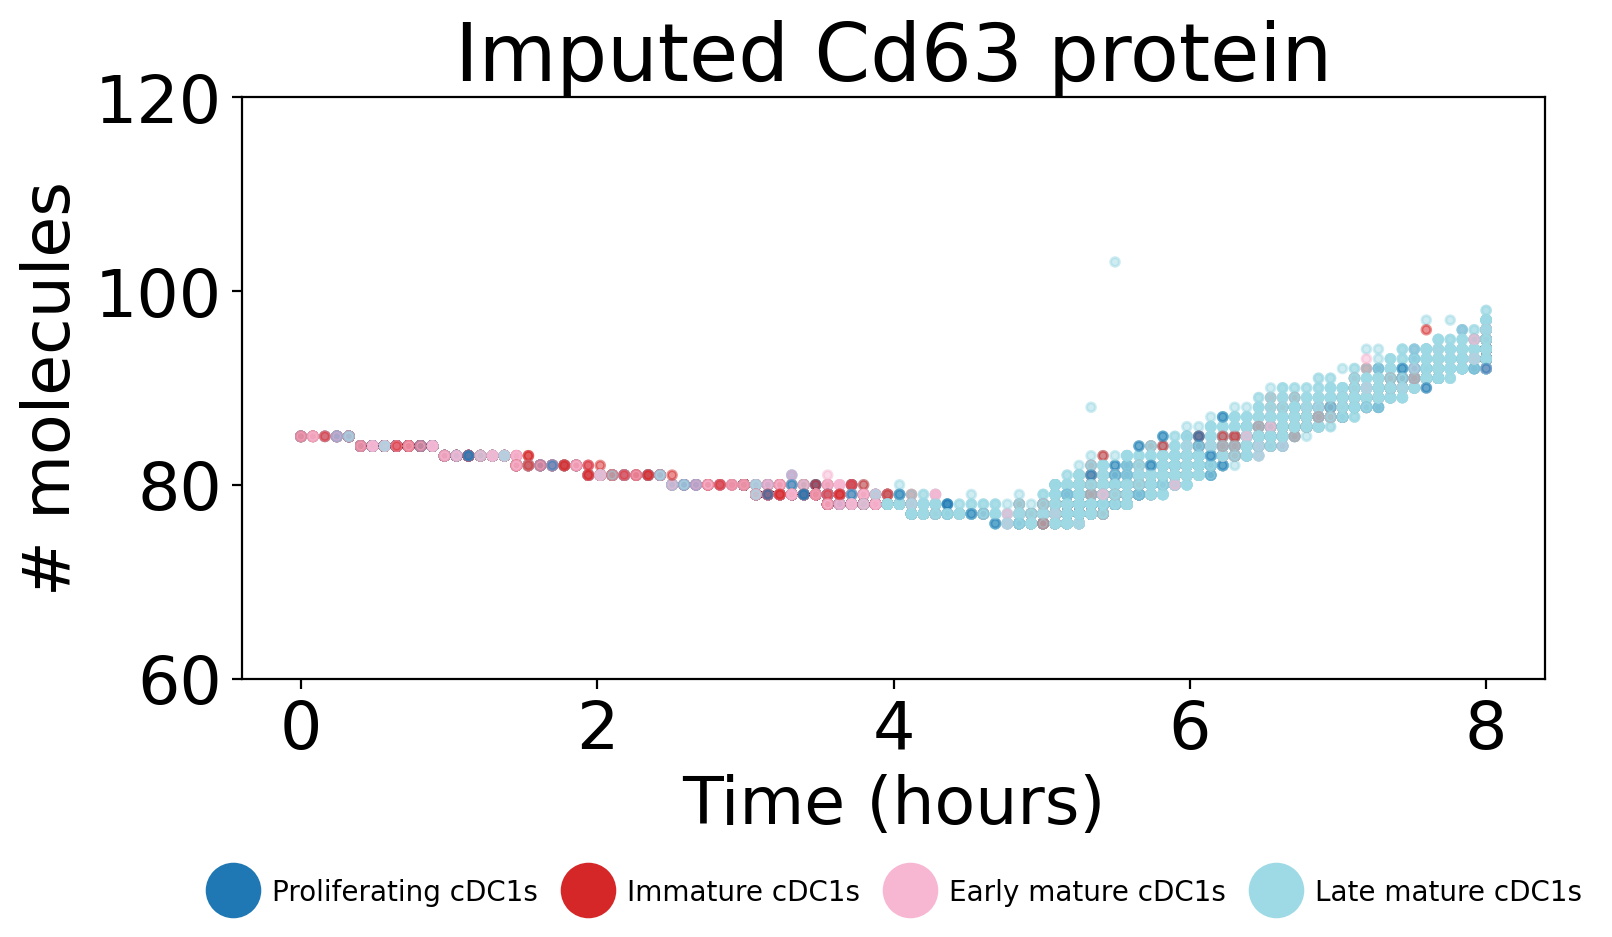

In [317]:
# --- Protein ---
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200)
ax.scatter(t_per_cell, expr_ADT_imputed_ordered[gene], c=codes, cmap=cmap, s=10, alpha=0.5)

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=cmap(i), markeredgecolor='none',
           markersize=20, label=str(lbl))   # smaller legend markers
    for i, lbl in enumerate(labels)
]

leg = ax.legend(
    handles=handles,
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),  # x centered; negative y puts it below
    ncol=5,                       # adjust based on how many clusters you have
    frameon=False,
    fontsize=10,                   # smaller legend text
    handletextpad=0.4,
    columnspacing=0.8
)

ax.set_title(f"Imputed {gene} protein" )
ax.set_xlabel("Time (hours)")
ax.set_ylabel("# molecules")

ax.set_ylim((60, 120))

# make room at the bottom for the legend
fig.subplots_adjust(bottom=0.30)   # increase if legend gets clipped
plt.show()

# I'm wondering: why are the protein estimates so high for some cell, especially at early time points, but considerably lower for cells at later time points? 

In [319]:
# Get indices of cells with disproportionately high imputed protein abundances

thresh = np.quantile(expr_ADT_imputed_ordered[gene], q=0.995)
hiprot_idx = np.where(expr_ADT_imputed_ordered[gene] > thresh)

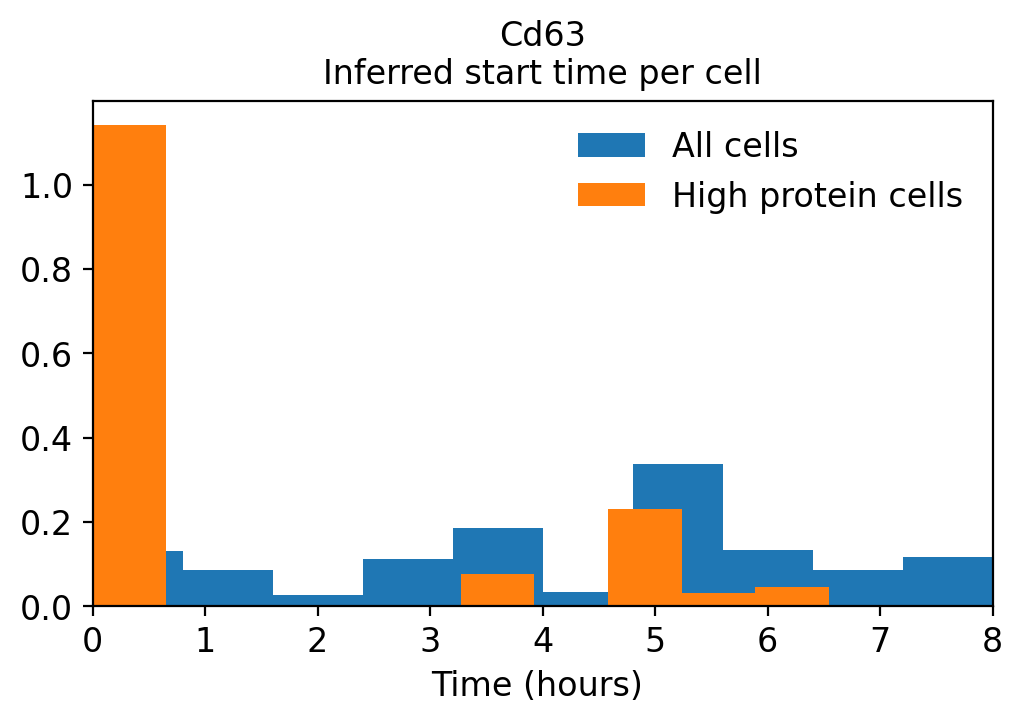

In [320]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.hist(t_per_cell, label="All cells", density=True)
ax.hist(t_per_cell[hiprot_idx], label="High protein cells", density=True)
ax.set_title(f"{gene}\nInferred start time per cell", fontsize=12)
ax.set_xlabel("Time (hours) ", fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xlim((0, 8))
ax.legend(frameon=False, fontsize=12)
plt.show()

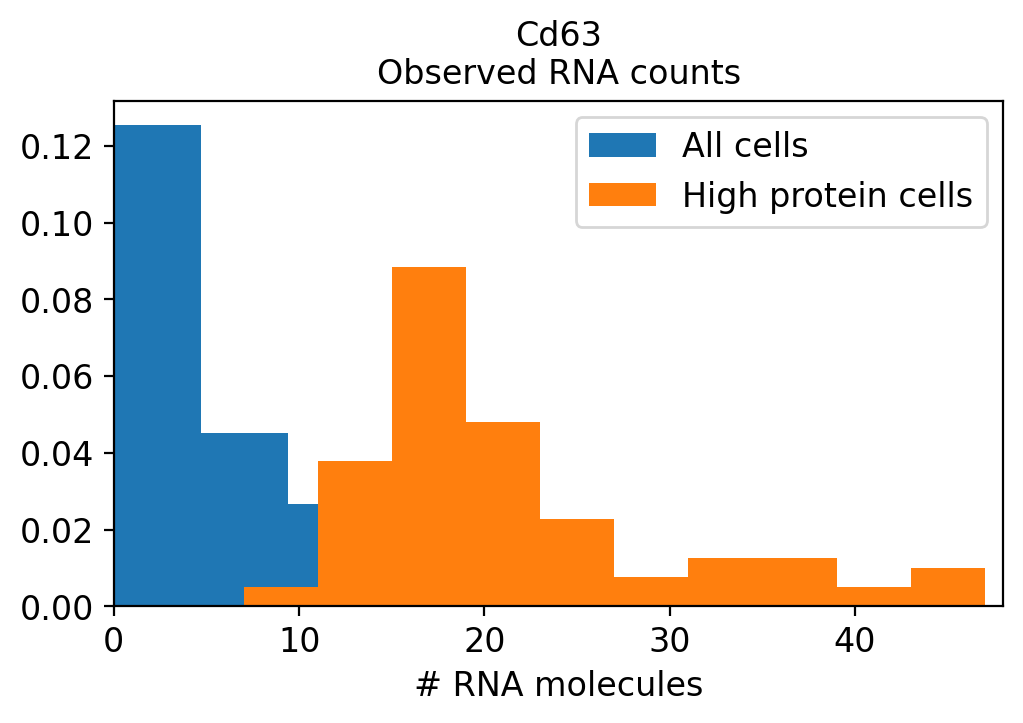

In [321]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.hist(expr_RNA_ordered[gene], label="All cells", density=True)
ax.hist(expr_RNA_ordered.iloc[hiprot_idx][gene], label="High protein cells", density=True)
ax.set_title(f"{gene}\nObserved RNA counts", fontsize=12)
ax.set_xlabel("# RNA molecules", fontsize=12)
ax.tick_params(labelsize=12)
ax.set_xlim((0, np.max(expr_RNA_ordered.iloc[hiprot_idx][gene]) + 1))
ax.legend(frameon=True, fontsize=12)
plt.show()

In [322]:
max_t_idx = 10

X_bw_hiprot = X_bw_ordered[hiprot_idx, :max_t_idx].astype(float)  # shape: (n_cells, 10)
X_bw_hiprot[X_bw_hiprot == -1] = np.nan

X_bw_all = X_bw_ordered[:, :max_t_idx].astype(float)
X_bw_all[X_bw_all == -1] = np.nan

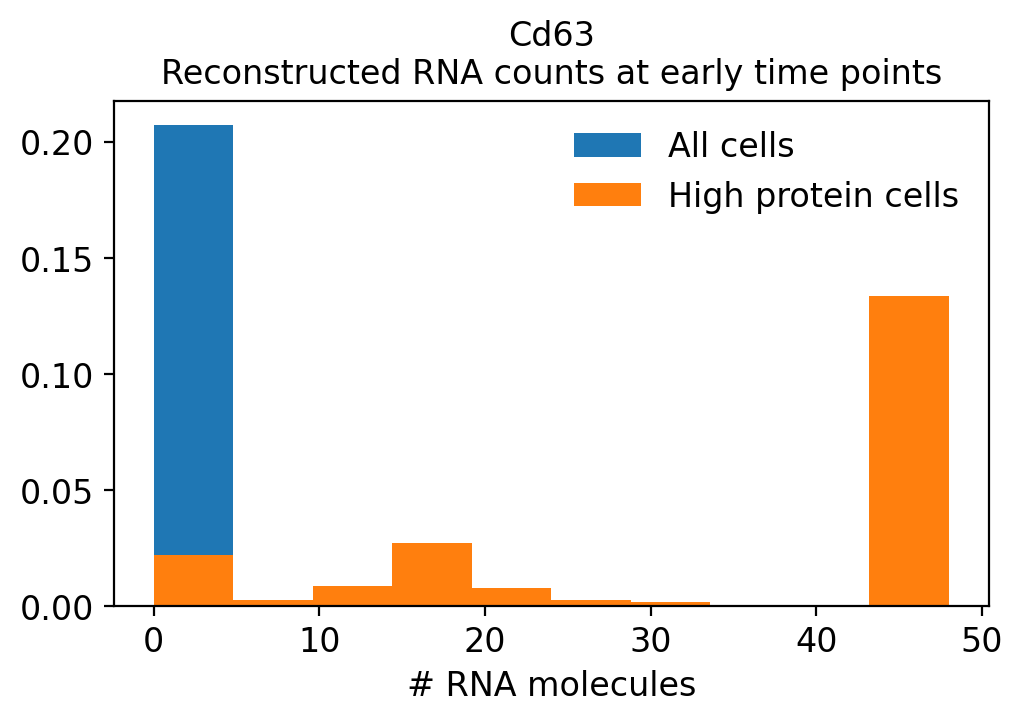

In [323]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.hist(X_bw_all.flatten(), label="All cells", density=True)
ax.hist(X_bw_hiprot.flatten(), label="High protein cells", density=True)
ax.set_title(f"{gene}\nReconstructed RNA counts at early time points", fontsize=12)
ax.set_xlabel("# RNA molecules", fontsize=12)
ax.tick_params(labelsize=12)
# ax.set_xlim((0, np.max(expr_RNA_ordered.iloc[hiprot_idx][gene]) + 1))
ax.legend(frameon=False, fontsize=12)
plt.show()

In [324]:
X_bw_hiprot = X_bw_ordered[hiprot_idx, :].astype(float)  # shape: (n_cells, 10)
X_bw_hiprot[X_bw_hiprot == -1] = np.nan

X_bw_all = X_bw_ordered.astype(float)
X_bw_all[X_bw_all == -1] = np.nan

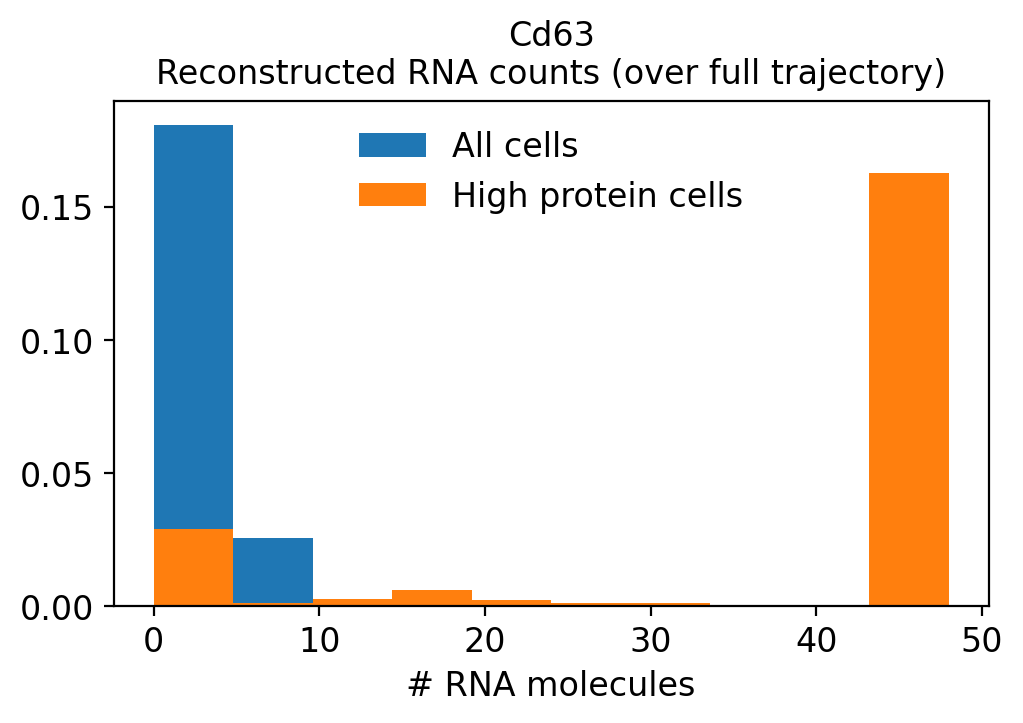

In [325]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.hist(X_bw_all.flatten(), label="All cells", density=True)
ax.hist(X_bw_hiprot.flatten(), label="High protein cells", density=True)
ax.set_title(f"{gene}\nReconstructed RNA counts (over full trajectory)", fontsize=12)
ax.set_xlabel("# RNA molecules", fontsize=12)
ax.tick_params(labelsize=12)
# ax.set_xlim((0, np.max(expr_RNA_ordered.iloc[hiprot_idx][gene]) + 1))
ax.legend(frameon=False, fontsize=12)
plt.show()

### It looks like the issue is that cells from later in the trajectory all have RNA abundances that are the same since they revert to the mean by that point.

### Cells earlier in the trajectory still retain some variability, so many more cells have larger starting RNA abundances, hence higher imputed protein levels

## Calculate correlation between early RNA abundance and imputed protein



In [326]:
X_bw_all = X_bw_ordered.astype(float)
X_bw_all[X_bw_all == -1] = np.nan

In [327]:
X_bw_all = X_bw_ordered.astype(float)
X_bw_all[X_bw_all == -1] = np.nan

In [328]:
early_abund = np.nansum(X_bw_all[:, :5], axis=1)

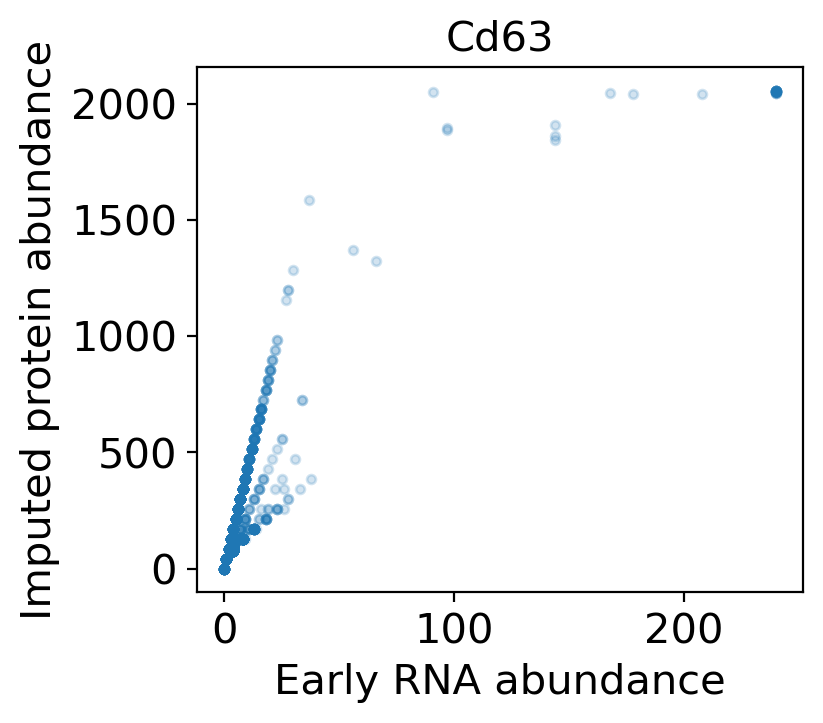

In [329]:
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=200) 
ax.scatter(early_abund, expr_ADT_imputed_ordered[gene], s=10, alpha=0.2)
ax.set_title(f"{gene}", fontsize=15)
ax.set_xlabel("Early RNA abundance", fontsize=15)
ax.set_ylabel("Imputed protein abundance", fontsize=15)
ax.tick_params(labelsize=15)

(0.0, 2000.0)

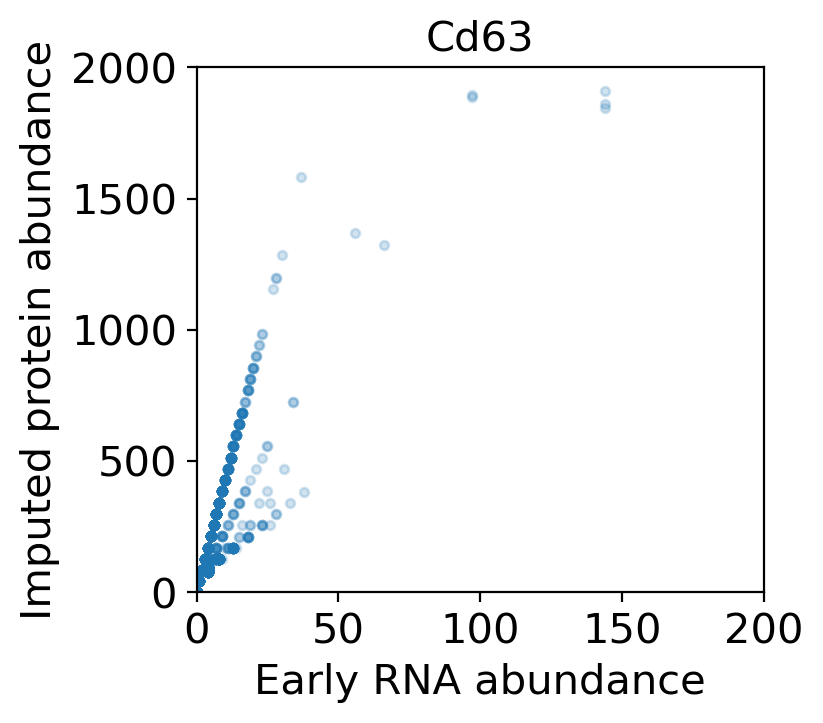

In [331]:
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=200) 
ax.scatter(early_abund, expr_ADT_imputed_ordered[gene], s=10, alpha=0.2)
ax.set_title(f"{gene}", fontsize=15)
ax.set_xlabel("Early RNA abundance", fontsize=15)
ax.set_ylabel("Imputed protein abundance", fontsize=15)
ax.tick_params(labelsize=15)
ax.set_xlim((0, 200))
ax.set_ylim((0, 2000))

## Compare reconstructed vs. simulated trajectories

In [280]:
import os
import sys
import glob
import pickle
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

from protein_from_RNA import *
from reconstruct_RNA_history import *

In [281]:
# Get traj object from running Chronocell

with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Extract varies objects/parameters needed to simulate data

Y = traj.X
Q = traj.Q[:, 0, :] 
t = traj.t
theta = traj.theta
tau = traj.tau # State transition times (global)
topo = traj.topo 
# state_grid = np.searchsorted(tau, t, side="left") - 1
# state_grid[0] = 0 

# Subset data to genes of interest (with protein measurements)

genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Order of genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist()
gene_df = genes['Gene_symbol'][gene_idx]

Y = Y[:, gene_idx, :]
theta = theta[gene_idx, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)
    
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
    states_per_gene = pickle.load(f)


In [282]:
# Generate ground-truth simulated data

n = 100 # No. cells
random_seed = 666

Y_observed, Y_sim, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

In [283]:
# Focus on one gene:

gene_idx = np.where(gene_df == gene)[0][0]

In [284]:
# Get forward trajectories
states = states_per_gene[gene_idx]
X_fwd = X_fwd_per_gene[gene_idx]
U_fwd, S_fwd = highest_prob_state_in_X_fwd(X_fwd, states)

# Load backward trajectories
gene_str = gene_df.iloc[gene_idx]
pattern = os.path.join("data/RNA_history_per_gene", f"*_{gene_str}_S*")
file = glob.glob(pattern)[0]

with open(file, "rb") as f:
    X_bw_S = pickle.load(f)

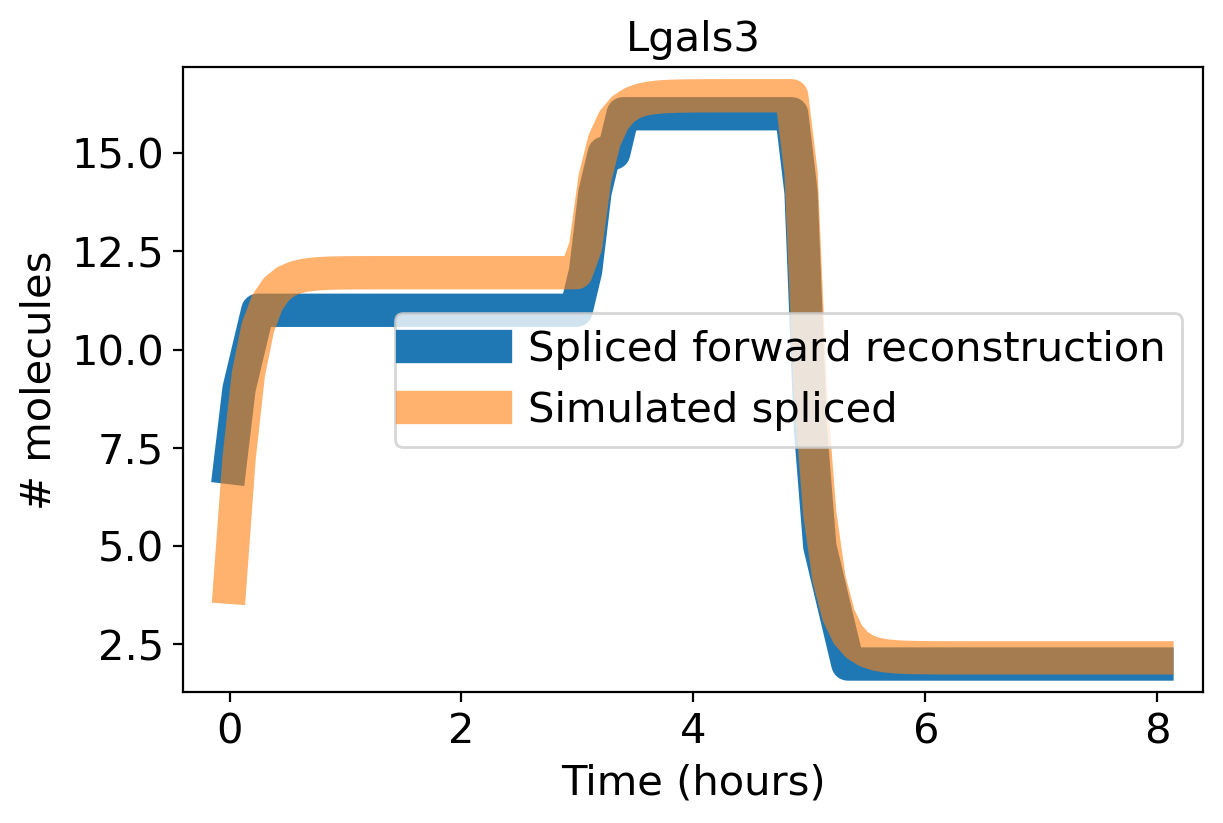

In [285]:
# First compare simulated vs. forward trajectory

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)  # display dpi
ax.plot(t, S_fwd, label="Spliced forward reconstruction")
ax.plot(true_t, Y_sim[:, gene_idx, 1], label="Simulated spliced", alpha=0.6)

ax.legend(fontsize=15)
ax.set_title(f"{gene_df.iloc[gene_idx]}", fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=15)
ax.set_ylabel("# molecules", fontsize=15)
ax.tick_params(labelsize=15)

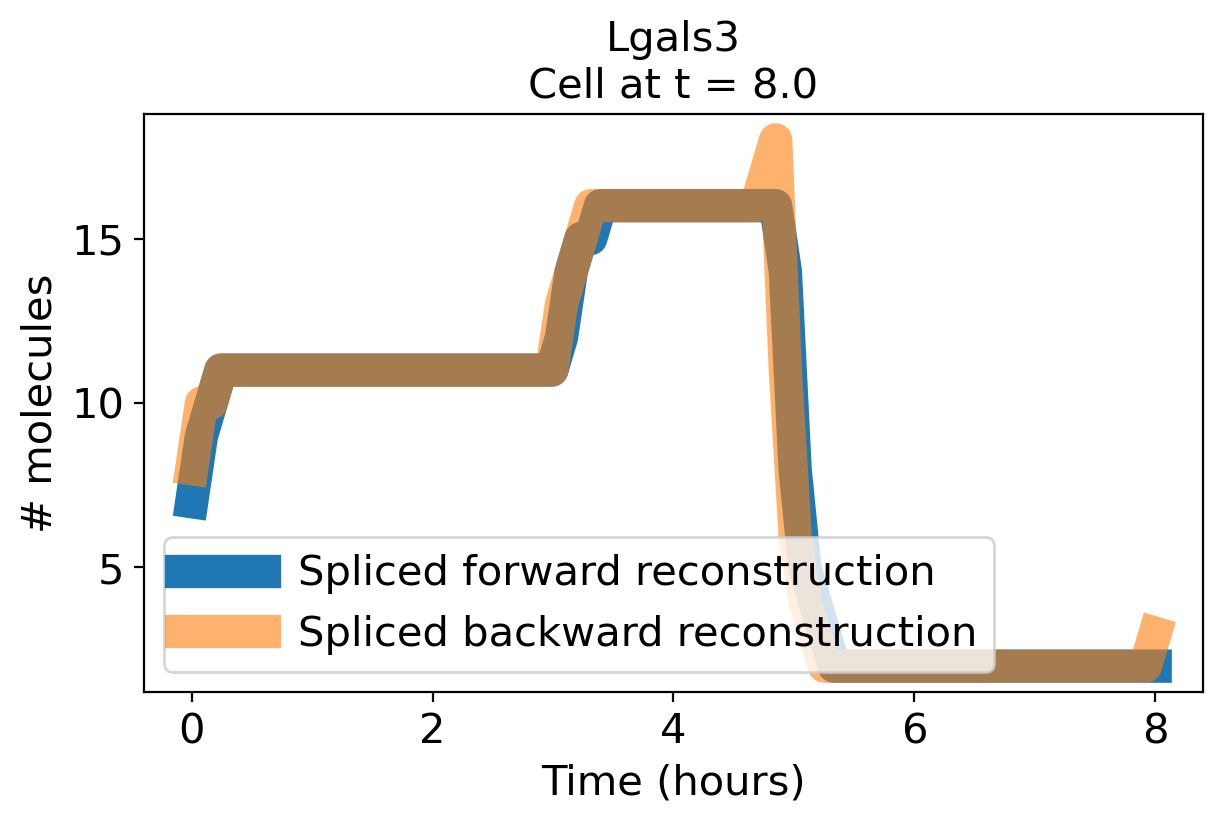

In [286]:
# Now compare forward vs. backward trajectory

# Pick cell at the end of trajectory:


t_obs = np.argmax(Q, axis=1)

t_idx = 99

cell_idx = np.where(t_obs == t_idx)[0][0]
start_idx = np.where(X_bw_S[cell_idx, :] > -1)[0][-1] + 1

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)  # display dpi
ax.plot(t[:start_idx], S_fwd[:start_idx], label="Spliced forward reconstruction")
ax.plot(t[:start_idx], X_bw_S[cell_idx, :start_idx], label="Spliced backward reconstruction", alpha=0.6)

ax.legend(fontsize=15)
ax.set_title(f"{gene_df.iloc[gene_idx]}\nCell at t = {np.round(t[t_idx], 3)}", size=15)
ax.set_xlabel("Time (hours)", fontsize=15)
ax.set_ylabel("# molecules", fontsize=15)
ax.tick_params(labelsize=15)

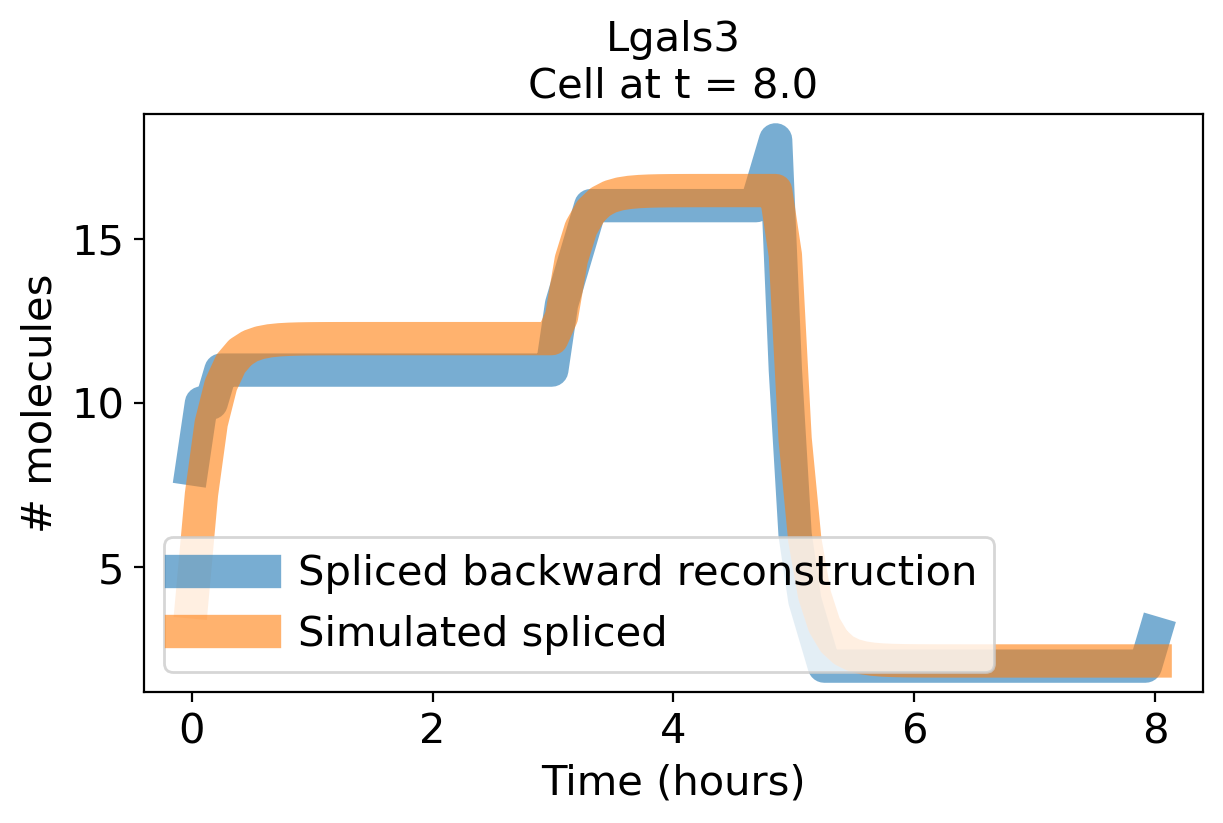

In [287]:
# Now compare simulated vs. backward trajectory

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)  # display dpi
ax.plot(t[:start_idx], X_bw_S[cell_idx, :start_idx], label="Spliced backward reconstruction", alpha=0.6)
ax.plot(true_t[:start_idx], Y_sim[:start_idx, gene_idx, 1], label="Simulated spliced", alpha=0.6)

ax.legend(fontsize=15)
ax.set_title(f"{gene_df.iloc[gene_idx]}\nCell at t = {np.round(t[t_idx], 3)}", size=15)
ax.set_xlabel("Time (hours)", fontsize=15)
ax.set_ylabel("# molecules", fontsize=15)
ax.tick_params(labelsize=15)

## Double check my new protein imputation code is correct with simulated data

In [78]:
# Now let's try simulating protein using reconstructed RNA and kinetic parameters for the working gene

In [197]:
tau = traj.tau # State transition times (global)
topo = traj.topo
true_t = traj.t
true_l = np.repeat(0, len(t)) 

# Get deg. rate for gene of interst

data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")
subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)
    
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)

half_life_cols = [col for col in df.columns if "Half-life" in col]
df_deg = np.log(2)/df[half_life_cols]
median_deg = np.nanmedian(df_deg, axis=1)

In [198]:
deg_rate = median_deg[np.where(df['Gene'] == gene)[0][0]]
deg_rate

np.float64(0.04471917293935131)

In [199]:
phi = np.zeros((1, 2))
phi[:,0] = 1
phi[:,-1] = deg_rate

In [200]:
# Load imputed RNA for working gene (only spliced RNA was loaded above)

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_S = pickle.load(f)
    
file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_U_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_U = pickle.load(f)

In [201]:
X_bw_S_ordered = X_bw_S[cell_order_idx, :]
X_bw_U_ordered = X_bw_U[cell_order_idx, :]

In [202]:
def simulate_protein_from_RNA(Y, topo, true_t, true_l, phi, step_size, random_seed=0):
    ## phi: Protein params
    np.random.seed(random_seed)
    
    L = len(topo) # No. lineages
    n = Y.shape[0] // L # No. cells per lineage
    p = Y.shape[1] # No. genes
    
    y0 = Y[0, :, 1] # RNA abundance per gene at state 0
    ss_rate = phi[:, 0] / phi[:, -1] # Steady-state protein production rate = transl_rate/deg_rate
    p0 = ss_rate * y0 # Initial protein abundance assuming steady-state
    print("y0:", y0)
   
    # Protein production paramters:
    transl_rates = phi[:, 0].T
    deg_rates = phi[:, -1].reshape((1, -1))
    
    P = np.zeros((n*L, p))
    
    for l in range(L):
        t_l = true_t[true_l == l] # Time points/cells in lineage l     
        dt = np.repeat(step_size, len(t_l)) # np.diff(t_l, prepend=-t_l[1]) # Time step size for each cell along the trajectory
        t_l = t_l.reshape((-1, 1)) 
        y_l = Y[l*n:(l+1)*n, :, 1] # Spliced RNAs for lineage l
        
        p_l = p0 * np.exp(-deg_rates * t_l) # Pre-existing protein that has not yet degraded
        print("p_old:", p_l[-1])
        
        t_diff = t_l - t_l.T # Rows = target time; columns = past times; e.g. t_diff[m, i] = time difference between t_m and t_i 
        decay_matrix = np.exp(-t_diff[:, :, None] * deg_rates) # Decay_matrix[m, i, p] = decay factor for protein abundance at t_m from RNA available at t_i for gene p
        mask = (t_diff >= 0)[:, :, None]
        mask = np.broadcast_to(mask, decay_matrix.shape)
        decay_matrix = np.where(mask, decay_matrix, 0) # Protein abundance at time t_m can't come from RNA at time t_i > t_m
        
        y_l_dt = y_l * dt[:, None] # Multiply each timepoint's RNA by its corresponding time step size (Riemann approximation)
        # Note to self: protein produced from RNA from time t = m can only be produced during the interval it was measured over, hence: scale RNA contribution at that time step by its time step size
        protein_contrib = (decay_matrix * y_l_dt[None, :, :]).sum(axis=1) # Integrate RNA counts still surviving up to each time point
        # Note to self: protein_contrib[target_idx, gene_idx] = np.sum(decay_matrix[target_time, :(target_time + 1), gene_idx] * y_l_dt[None, :(target_time + 1), gene_idx])
        P[l*n:(l+1)*n] = p_l + transl_rates * protein_contrib # Protein abundance in each cell = pre-existing protein + newly synthesized protein
        print("p_new:", (transl_rates * protein_contrib)[-1])
        print("P:", P[l*n:(l+1)*n][-1])
         
    P_observed = np.random.poisson(P)
        
    return P_observed, P, y0

In [203]:
step_size = t[1] - t[0]

In [204]:
subset_idx = np.where(t_per_cell <= 8)[0]
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 0.0
y0: [2.]
p_old: [44.72354627]
p_new: [0.]
P: [44.72354627]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [1.]
p_old: [22.36177313]
p_new: [0.]
P: [22.36177313]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [1.]
p_old: [22.36177313]
p_new: [0.]
P: [22.36177313]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [0.]
p_old: [0.]
p_new: [0.]
P: [0.]
Inferfed t: 0.0
y0: [1.]
p_old: [22.36177313]
p_new: [0.]
P: [22.36177313]
Inferfed t: 0.0
y0: [1.]
p_old: [22.36177313]
p_new: [0.]
P: [22.36177313]
Inferfed t: 0.0
y0: [3.]
p_old: [67.0853194]
p_new: [0.]
P: [67.0853194]
Inferfed t: 0.0
y0: [1.]
p_old: [22.36177313]
p_new: [0.]
P: [22.36177313]
Inferfed t: 0.0
y0: [

In [206]:
np.corrcoef(expr_ADT_imputed_ordered[gene].iloc[subset_idx], P_curr)

array([[1.        , 0.99716893],
       [0.99716893, 1.        ]])

### Almost identitical. Which means that imputation code is working fine.